# 🚀 **Парсер судебной практики с сайта Sudact.ru** 🚀

---

## 📋 **Описание задачи**

Разработать парсер для сайта [Sudact.ru](https://sudact.ru/), который состоит из двух основных компонент:

### **1. Первичный парсинг**
- **Входные пользовательские данные**: наименование суда, целевой период, текстовый запрос (например, "незаконное использование товарного знака").
- **Действия**:
  - имитация действий пользователя на сайте для поиска релевантной судебной практики.
  - извлечение первичной информации: номер дела, дата судебного решения, текст гиперссылки.
- **Результат**: Датасет, очищенный с использованием регулярных выражений, сохраненный для дальнейшего использования.

### **2. Углубленный парсинг**
- **Действия**:
  - Парсинг страниц с текстами судебных решений с использованием датасета, полученного на первом этапе.
  - Извлечение ключевой информации из текстов судебных решений:
    - Предмет иска.
    - Резолютивная часть судебного акта.
    - Целевые суммы, соответствующие текстовому запросу.
- **Результат**: Датасет с предобработанными данными, объединенный с первичным датасетом.

---

## 🛠 **Этапы выполнения**

1. **Первичный парсинг**:
   - имитация поиска на сайте Sudact.ru;
   - извлечение и очистка данных с использованием регулярных выражений;
   - сохранение промежуточного датасета.

2. **Углубленный парсинг**:
   - Парсинг страниц с текстами решений.
   - Извлечение из текстов предмета иска, резолютивной части и целевых сумм.
   - Предобработка данных и сохранение в датафрейм.

3. **Объединение данных**:
   - Горизонтальная конкатенация двух датафреймов.
   - Проведение EDA (Exploratory Data Analysis) для анализа итогового датасета.

---

## 🧩 **Сложности, с которыми предстоит столкнуться**


1. **Капча и защита от парсинга**:
   - Sudact.ru может иметь защиту от автоматизированных запросов, включая капчу. Это потребует дополнительных усилий для обхода, особенного учитывая, что предполагается вариабельная имитация полноценного пользователя.

2. **Неструктурированные данные**:
   - Тексты судебных решений не имеют заранее заданной структуры: каждый судья может иметь свой собственный стиль, что затрудняет извлечение и без того неструктурированной информации. Потребуется тщательная работа с регулярными выражениями.

3. **Ограничения на частоту запросов**:
   - настройки на сервере, скорее всего, ограничивают количество запросов в единицу времени: необходимо реализовать рандомные задержки между запросами, использовать user_agent и др. инструменты, чтобы избежать блокировки.

### Устновим необходимые библиотеки

In [1]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
! pip install selenium

In [3]:
pip install user_agent

Note: you may need to restart the kernel to use updated packages.


In [4]:
from selenium import webdriver
#импортируем класс By,который позволяет выбрать способ поиска элемента
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.action_chains import ActionChains

In [5]:
from user_agent import generate_user_agent

In [6]:
# Импортируем необходимые библиотеки
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import re
import seaborn as sns
import time
from bs4 import BeautifulSoup
from datetime import datetime
from time import sleep
from tqdm import tqdm

### Инициализация вебдрайвера и переход на целевую страницу для парсинга

In [7]:
def init_chrome_driver(headless=True, user_agent=None):
    """
    Инициализация Chrome WebDriver с настройками.

    :param headless: запуск в headless-режиме (без отображения окна браузера)
    :param user_agent: строка user-agent; если None, генерируется случайный
    :return: настроенный экземпляр WebDriver.
    """
    if user_agent is None:
        user_agent = generate_user_agent(os='win', navigator='chrome')

    chrome_options = Options()
    chrome_options.add_argument(f'user-agent={user_agent}')

    if headless:
        chrome_options.add_argument('--headless')
    # скрывает признаки автоматизации (например, чтобы сайты не блокировали запросы).
    chrome_options.add_argument('--disable-blink-features=AutomationControlled') 
    chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"])
    chrome_options.add_experimental_option('useAutomationExtension', False)
    driver = webdriver.Chrome(options=chrome_options)
    return driver

In [8]:
def fake_user(court: str, query: str, start: str, end: str):
    """
    Функция для имитации действий пользователя при поиске данных.

    :param court: название суда (строка)
    :param query: текст запроса (строка)
    :param start: начальная дата в формате строки
    :param end: конечная дата в формате строки
    :return: инициализированный драйвер для дальнейшей работы.
    """
    # Инициализация драйвера
    driver = init_chrome_driver(headless=False)  # headless=False для отладки
    
    try:
        # переход на целевую страницу
        url = 'https://sudact.ru/'
        #инициализация драйвера браузера.
        driver.get(url)
        # нажатие на кнопку "Арбитражные суды"
        button_1 = driver.find_element(By.LINK_TEXT, 'Арбитражные суды') 
        button_1.send_keys(Keys.ENTER)
        # ввод текстового запроса
        text_button = driver.find_element(By.XPATH, '//*[@id="id_arbitral-txt"]')
        text_button.send_keys(query)
        # ввод названия суда
        court_button = driver.find_element(By.XPATH, '//*[@id="id_arbitral-court"]')
        court_button.send_keys(court)
        # ввод дат (начальной и конечной)
        date_button_left = driver.find_element(By.XPATH, '//*[@id="id_arbitral-date_from"]')
        date_button_left.send_keys(start)
        # ввод дат (начальной и конечной)
        date_button_right = driver.find_element(By.XPATH, '//*[@id="id_arbitral-date_to"]')
        date_button_right.send_keys(end)
        # нажатие кнопки поиска
        search_button = driver.find_element(By.XPATH, '//*[@id="arbitral-searchForm"]/table/tbody/tr[15]/td/input')
        search_button.send_keys(Keys.ENTER)
        # сохраняем текущую инициализацию драйвера для дальнейшей работы
        return driver
    
    except Exception as e:
        print(f"Произошла ошибка: {e}")
        driver.quit()
        return None

In [9]:
# Задаем параметры поиска
search_params = {
    "Court": "АС города Москвы",
    "query_text": "за незаконное использование товарного знака",
    "start_date": "01062023",
    "end_date": "31082023"
}

In [10]:
driver = fake_user(
    court=search_params["Court"],
    query=search_params["query_text"],
    start=search_params["start_date"],
    end=search_params["end_date"]
)

### Первичный парсинг

**Парсинг будет осуществляться согласно следующим входным параметрам**:
- текстовый запрос: "незаконное использование товарного знака"
- суды: арбитражный суд города Москвы (АСГМ), арбитражный суд Новосибирской области (АС НСО)
- периоды: 01062023-31082023, 01012023-31032023, 01012024-31032024, 01092023-30112023

**Создадим функции для извлечения и преобразования дат (принятия суд решения) + номера судебного дела**

In [11]:
# словарь для преобразования русских месяцев в числовой формат
month_to_number = {
    'января': '01',
    'февраля': '02',
    'марта': '03',
    'апреля': '04',
    'мая': '05',
    'июня': '06',
    'июля': '07',
    'августа': '08',
    'сентября': '09',
    'октября': '10',
    'ноября': '11',
    'декабря': '12'
}
# Функция для извлечения и преобразования даты
def extract_and_format_date(text):
    # Регулярное выражение для извлечения даты
    date_pattern = r'(\d{1,2})\s+(января|февраля|марта|апреля|мая|июня|июля|августа|сентября|октября|ноября|декабря)\s+(\d{4})'
    date_match = re.search(date_pattern, text)
    
    if date_match:
        day = date_match.group(1).zfill(2)  # Добавляем ведущий ноль, если день однозначный
        month_ru = date_match.group(2)      # Русский месяц
        year = date_match.group(3)[-2:]     # Берем последние две цифры года     
        # Преобразуем русский месяц в числовой формат
        month_num = month_to_number.get(month_ru, '00')  # '00' в случае ошибки       
        # Собираем дату в формате дд-мм-гг
        formatted_date = f"{day}-{month_num}-{year}"
        return formatted_date
    return 'дата не найдена'
# Функция для извлечения номера дела
def extract_case_number(text):
    # Регулярное выражение для извлечения номера дела
    case_number_pattern = r'№\s*(А.*\d)'
    case_number_match = re.search(case_number_pattern, text)
    if case_number_match:
        return case_number_match.group(1)
    return 'номер не найден'
# Текст для тренировочного поиска
text = "Решение от 2 апреля 2024 г. по делу № А40-276468/2023"
formatted_date = extract_and_format_date(text)
case_number = extract_case_number(text)
print("Извлеченная дата:", formatted_date)
print("Извлеченный номер дела:", case_number)

Извлеченная дата: 02-04-24
Извлеченный номер дела: А40-276468/2023


Потестим: вытащим со страницы решения с реквизитами и ссылки

In [12]:
result = driver.find_element(By.CLASS_NAME, 'results')
list_links = result.find_elements(By.TAG_NAME,'a')
for i in list_links[:3]:
    print(i.text)
    print(i.get_attribute('href'))

Решение от 4 сентября 2023 г. по делу № А40-119392/2023
https://sudact.ru/arbitral/doc/ChAWZWaKMuNW/?arbitral-txt=%D0%B7%D0%B0+%D0%BD%D0%B5%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5+%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5+%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BD%D0%BE%D0%B3%D0%BE+%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0&arbitral-case_doc=&arbitral-lawchunkinfo=&arbitral-date_from=01.06.2023&arbitral-date_to=31.08.2023&arbitral-region=&arbitral-court=%D0%90%D0%A1+%D0%B3%D0%BE%D1%80%D0%BE%D0%B4%D0%B0+%D0%9C%D0%BE%D1%81%D0%BA%D0%B2%D1%8B&arbitral-judge=&_=1758550344125&snippet_pos=2674#snippet
Решение от 25 августа 2023 г. по делу № А40-119633/2023
https://sudact.ru/arbitral/doc/HnbvXmeWAZNn/?arbitral-txt=%D0%B7%D0%B0+%D0%BD%D0%B5%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5+%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5+%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BD%D0%BE%D0%B3%D0%BE+%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0&arbitral-case_doc=

**Напишем функцию для извлечения дат, номеров дел и ссылок из результатов поиска на заданном количестве страниц**

In [13]:
def get_dates_nums_links(num_pages: int, court: str, query_text: str, start_date: str, end_date: str):

    data_init = []

    for page in tqdm(range(num_pages)):  # Обрабатываем первые 2 страницы (можно изменить)
        # Извлечение данных с текущей страницы
        results = driver.find_element(By.CLASS_NAME, 'results')
        items = results.find_elements(By.TAG_NAME,'a')

        for item in items:
            # Извлечение текста и ссылки
            text = item.text
            link = item.get_attribute('href')
            # Извлечение номера дела
            case_number = extract_case_number(text)
            # Извлечение даты
            date = extract_and_format_date(text)

            # Сохранение данных в список
            data_init.append({
                "court": court,  # Добавляем значение переменной court
                "query_text": query_text,  # Добавляем значение переменной query_text
                "start_date": start_date,  # Добавляем значение переменной start_date
                "end_date": end_date,  # Добавляем значение переменной end_date
                "case_number": case_number,  # Номер дела
                "decision_date": date,  # Дата
                "link": link  # Ссылка
            })
        time.sleep(10)
        # Переход на следующую страницу (если есть)
        try:
            next_button = driver.find_element(By.CLASS_NAME, 'page-next')
            next_button.click()
            driver.implicitly_wait(10)  # Ожидание загрузки следующей страницы
        except:
            print("Следующая страница не найдена.")
            break
    # Вывод результатов
    for item in data_init[:3]:
        print(item)
    # Закрытие драйвера
    return data_init

In [14]:
court=search_params["Court"]
query_text=search_params["query_text"]
start_date=search_params["start_date"]
end_date=search_params["end_date"]

**Далее, во избежание прекращение доступа (что случалось неоднократно, не смотря на предпринятые хитрости), обработаем по 70-100 целевых страниц согласно заданным параметрам**

Результаты в виде датафреймов будем сохранять в соотвествующих переменных

**Период: 010623-310823, АСГМ**

In [15]:
data_acm_summer_2023 = get_dates_nums_links(10, court, query_text, start_date, end_date)
driver.quit()

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [01:45<00:00, 10.59s/it]


{'court': 'АС города Москвы', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01062023', 'end_date': '31082023', 'case_number': 'А40-119392/2023', 'decision_date': '04-09-23', 'link': 'https://sudact.ru/arbitral/doc/ChAWZWaKMuNW/?arbitral-txt=%D0%B7%D0%B0+%D0%BD%D0%B5%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5+%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5+%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BD%D0%BE%D0%B3%D0%BE+%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0&arbitral-case_doc=&arbitral-lawchunkinfo=&arbitral-date_from=01.06.2023&arbitral-date_to=31.08.2023&arbitral-region=&arbitral-court=%D0%90%D0%A1+%D0%B3%D0%BE%D1%80%D0%BE%D0%B4%D0%B0+%D0%9C%D0%BE%D1%81%D0%BA%D0%B2%D1%8B&arbitral-judge=&_=1758550344125&snippet_pos=2674#snippet'}
{'court': 'АС города Москвы', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01062023', 'end_date': '31082023', 'case_number': 'А40-119633/2023', 'decision_date': '25-08-23', 'link': 

In [84]:
len(data_acm_summer_2023)

100

In [85]:
data_acm_summer_2023 = pd.DataFrame(data_acm_summer_2023)
data_acm_summer_2023.head(10)

,court,query_text,start_date,end_date,case_number,decision_date,link
0,АС города Москвы,за незаконное использование товарного знака,01062023,31082023,А40-120271/2022,28-08-23,https://sudact.ru/arbitral/doc/FmmCPA2vFP6v/?a...
1,АС города Москвы,за незаконное использование товарного знака,01062023,31082023,А40-134167/2023,24-08-23,https://sudact.ru/arbitral/doc/nEeyVq07nWbW/?a...
2,АС города Москвы,за незаконное использование товарного знака,01062023,31082023,А40-97665/2023,23-08-23,https://sudact.ru/arbitral/doc/4p8GEjPGSSQx/?a...
3,АС города Москвы,за незаконное использование товарного знака,01062023,31082023,А40-131645/2023,29-08-23,https://sudact.ru/arbitral/doc/zPIHb59UvY6T/?a...
4,АС города Москвы,за незаконное использование товарного знака,01062023,31082023,А40-133034/2023,22-08-23,https://sudact.ru/arbitral/doc/qfYhE6VvRcJa/?a...
5,АС города Москвы,за незаконное использование товарного знака,01062023,31082023,А40-133086/2023,23-08-23,https://sudact.ru/arbitral/doc/exDlhHYnb5HJ/?a...
6,АС города Москвы,за незаконное использование товарного знака,01062023,31082023,А40-102422/2023,21-08-23,https://sudact.ru/arbitral/doc/HU8mUVFlE2W/?ar...
7,АС города Москвы,за незаконное использование товарного знака,01062023,31082023,А40-132218/2023,18-08-23,https://sudact.ru/arbitral/doc/FHetl7pJr1mQ/?a...
8,АС города Москвы,за незаконное использование товарного знака,01062023,31082023,А40-102348/2023,21-08-23,https://sudact.ru/arbitral/doc/2pEG1pNhCrN1/?a...
9,АС города Москвы,за незаконное использование товарного знака,01062023,31082023,А40-132218/2023,09-08-23,https://sudact.ru/arbitral/doc/Y2j1ejUg0qr7/?a...


In [86]:
# Сохранение в Excel
data_acm_summer_2023.to_excel("data_acm_summer_2023.xlsx", index=False)

In [87]:
# Подсчет дубликатов
duplicates_count = data_acm_summer_2023.duplicated().sum()  # Считаем количество дубликатов
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 0


**Период: 01012023-31032023, АСГМ**

In [96]:
# Задаем новые параметры поиска и инициализируем
search_params = {
    "Court": "АС города Москвы",
    "query_text": "за незаконное использование товарного знака",
    "start_date": "01012023",
    "end_date": "31032023"
}
    
court=search_params["Court"]
query_text=search_params["query_text"]
start_date=search_params["start_date"]
end_date=search_params["end_date"]
    
driver = fake_user(
    court=search_params["Court"],
    query=search_params["query_text"],
    start=search_params["start_date"],
    end=search_params["end_date"]
)

In [97]:
data_acm_winter_2023 = get_dates_nums_links(10, court, query_text, start_date, end_date)
driver.quit()

{'court': 'АС города Москвы', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01012023', 'end_date': '31032023', 'case_number': 'А40-61276/2022', 'decision_date': '24-04-23', 'link': 'https://sudact.ru/arbitral/doc/zTa1fNdRWVUV/?arbitral-txt=%D0%B7%D0%B0+%D0%BD%D0%B5%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5+%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5+%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BD%D0%BE%D0%B3%D0%BE+%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0&arbitral-case_doc=&arbitral-lawchunkinfo=&arbitral-date_from=01.01.2023&arbitral-date_to=31.03.2023&arbitral-region=&arbitral-court=%D0%90%D0%A1+%D0%B3%D0%BE%D1%80%D0%BE%D0%B4%D0%B0+%D0%9C%D0%BE%D1%81%D0%BA%D0%B2%D1%8B&arbitral-judge=&snippet_pos=1988#snippet'}
{'court': 'АС города Москвы', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01012023', 'end_date': '31032023', 'case_number': 'А40-140571/2022', 'decision_date': '24-04-23', 'link': 'https://sudact.r

In [98]:
len(data_acm_winter_2023)

100

In [99]:
data_acm_winter_2023 = pd.DataFrame(data_acm_winter_2023)
data_acm_winter_2023.head(10)

,court,query_text,start_date,end_date,case_number,decision_date,link
0,АС города Москвы,за незаконное использование товарного знака,01012023,31032023,А40-61276/2022,24-04-23,https://sudact.ru/arbitral/doc/zTa1fNdRWVUV/?a...
1,АС города Москвы,за незаконное использование товарного знака,01012023,31032023,А40-140571/2022,24-04-23,https://sudact.ru/arbitral/doc/BAYLZZiZXqQj/?a...
2,АС города Москвы,за незаконное использование товарного знака,01012023,31032023,А40-128355/2022,31-03-23,https://sudact.ru/arbitral/doc/vjZunF9wzs6d/?a...
3,АС города Москвы,за незаконное использование товарного знака,01012023,31032023,А40-202040/2022,22-05-23,https://sudact.ru/arbitral/doc/cQWkYcF9w5Yx/?a...
4,АС города Москвы,за незаконное использование товарного знака,01012023,31032023,А40-202040/2022,28-03-23,https://sudact.ru/arbitral/doc/tY8nPH1OutUT/?a...
5,АС города Москвы,за незаконное использование товарного знака,01012023,31032023,А40-184691/2022,31-03-23,https://sudact.ru/arbitral/doc/tgwiw5ZMMLbl/?a...
6,АС города Москвы,за незаконное использование товарного знака,01012023,31032023,А40-281073/2022,29-03-23,https://sudact.ru/arbitral/doc/q7g3KRfnGkWQ/?a...
7,АС города Москвы,за незаконное использование товарного знака,01012023,31032023,А40-250466/2022,23-03-23,https://sudact.ru/arbitral/doc/XdNZbvxfZZmq/?a...
8,АС города Москвы,за незаконное использование товарного знака,01012023,31032023,А40-250466/2022,18-04-23,https://sudact.ru/arbitral/doc/dhE07U46rFUx/?a...
9,АС города Москвы,за незаконное использование товарного знака,01012023,31032023,А40-166608/2022,17-04-23,https://sudact.ru/arbitral/doc/pYjW2SuAboHx/?a...


In [100]:
# Сохранение в Excel
data_acm_winter_2023.to_excel("data_acm_winter_2023.xlsx", index=False)

In [107]:
# Подсчет дубликатов
duplicates_count = data_acm_winter_2023.duplicated().sum()  # Считаем количество дубликатов
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 0


**Период: 01012024-31032024, АСГМ**

In [111]:
# Задаем новые параметры поиска и инициализируем
search_params = {
    "Court": "АС города Москвы",
    "query_text": "за незаконное использование товарного знака",
    "start_date": "01012024",
    "end_date": "31032024"
}
    
court=search_params["Court"]
query_text=search_params["query_text"]
start_date=search_params["start_date"]
end_date=search_params["end_date"]
    
driver = fake_user(
    court=search_params["Court"],
    query=search_params["query_text"],
    start=search_params["start_date"],
    end=search_params["end_date"]
)

In [102]:
data_acm_winter_2024 = get_dates_nums_links(10, court, query_text, start_date, end_date)
driver.quit()

{'court': 'АС города Москвы', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01012024', 'end_date': '31032024', 'case_number': 'А40-276468/2023', 'decision_date': '02-04-24', 'link': 'https://sudact.ru/arbitral/doc/HHeCCFAM7Jdv/?arbitral-txt=%D0%B7%D0%B0+%D0%BD%D0%B5%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5+%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5+%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BD%D0%BE%D0%B3%D0%BE+%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0&arbitral-case_doc=&arbitral-lawchunkinfo=&arbitral-date_from=01.01.2024&arbitral-date_to=31.03.2024&arbitral-region=&arbitral-court=%D0%90%D0%A1+%D0%B3%D0%BE%D1%80%D0%BE%D0%B4%D0%B0+%D0%9C%D0%BE%D1%81%D0%BA%D0%B2%D1%8B&arbitral-judge=&snippet_pos=908#snippet'}
{'court': 'АС города Москвы', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01012024', 'end_date': '31032024', 'case_number': 'А40-282295/2023', 'decision_date': '08-02-24', 'link': 'https://sudact.r

In [112]:
len(data_acm_winter_2024)

100

In [104]:
data_acm_winter_2024 = pd.DataFrame(data_acm_winter_2024)
data_acm_winter_2024.head(10)

,court,query_text,start_date,end_date,case_number,decision_date,link
0,АС города Москвы,за незаконное использование товарного знака,01012024,31032024,А40-276468/2023,02-04-24,https://sudact.ru/arbitral/doc/HHeCCFAM7Jdv/?a...
1,АС города Москвы,за незаконное использование товарного знака,01012024,31032024,А40-282295/2023,08-02-24,https://sudact.ru/arbitral/doc/ai7tjKJceugt/?a...
2,АС города Москвы,за незаконное использование товарного знака,01012024,31032024,А40-221895/2023,30-01-24,https://sudact.ru/arbitral/doc/vNg45QIbRZdg/?a...
3,АС города Москвы,за незаконное использование товарного знака,01012024,31032024,А40-273181/2023,07-03-24,https://sudact.ru/arbitral/doc/xbFcgrAN9eN1/?a...
4,АС города Москвы,за незаконное использование товарного знака,01012024,31032024,А40-282200/2023,12-02-24,https://sudact.ru/arbitral/doc/3zuBG0xZqpZg/?a...
5,АС города Москвы,за незаконное использование товарного знака,01012024,31032024,А40-283634/2023,14-02-24,https://sudact.ru/arbitral/doc/gsqBim8Y2mdd/?a...
6,АС города Москвы,за незаконное использование товарного знака,01012024,31032024,А40-221895/2023,07-02-24,https://sudact.ru/arbitral/doc/o6O0bO4wLPHu/?a...
7,АС города Москвы,за незаконное использование товарного знака,01012024,31032024,А40-198011/2023,28-03-24,https://sudact.ru/arbitral/doc/2WwDTZXuSQYN/?a...
8,АС города Москвы,за незаконное использование товарного знака,01012024,31032024,А40-278212/2023,04-03-24,https://sudact.ru/arbitral/doc/0IR16Hdo1JmI/?a...
9,АС города Москвы,за незаконное использование товарного знака,01012024,31032024,А40-292359/2023,29-01-24,https://sudact.ru/arbitral/doc/ihMZGXA4S1xO/?a...


In [105]:
# Сохранение в Excel
data_acm_winter_2024.to_excel("data_acm_winter_2024.xlsx", index=False)

In [106]:
# Подсчет дубликатов
duplicates_count = data_acm_winter_2024.duplicated().sum()  # Считаем количество дубликатов
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 0


**Период: 01092023-30112023, АСГМ**

In [115]:
# Задаем новые параметры поиска и инициализируем
search_params = {
    "Court": "АС города Москвы",
    "query_text": "за незаконное использование товарного знака",
    "start_date": "01092023",
    "end_date": "30112023"
}
    
court=search_params["Court"]
query_text=search_params["query_text"]
start_date=search_params["start_date"]
end_date=search_params["end_date"]
    
driver = fake_user(
    court=search_params["Court"],
    query=search_params["query_text"],
    start=search_params["start_date"],
    end=search_params["end_date"]
)

In [116]:
data_acm_autemn_2023 = get_dates_nums_links(10, court, query_text, start_date, end_date)
driver.quit()

{'court': 'АС города Москвы', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01092023', 'end_date': '30112023', 'case_number': 'А40-225931/2023', 'decision_date': '29-11-23', 'link': 'https://sudact.ru/arbitral/doc/4gOWBf7lkwbj/?arbitral-txt=%D0%B7%D0%B0+%D0%BD%D0%B5%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5+%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5+%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BD%D0%BE%D0%B3%D0%BE+%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0&arbitral-case_doc=&arbitral-lawchunkinfo=&arbitral-date_from=01.09.2023&arbitral-date_to=30.11.2023&arbitral-region=&arbitral-court=%D0%90%D0%A1+%D0%B3%D0%BE%D1%80%D0%BE%D0%B4%D0%B0+%D0%9C%D0%BE%D1%81%D0%BA%D0%B2%D1%8B&arbitral-judge=&snippet_pos=216#snippet'}
{'court': 'АС города Москвы', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01092023', 'end_date': '30112023', 'case_number': 'А40-164532/2023', 'decision_date': '29-11-23', 'link': 'https://sudact.r

In [117]:
len(data_acm_autemn_2023)

100

In [118]:
data_acm_autemn_2023 = pd.DataFrame(data_acm_autemn_2023)
data_acm_autemn_2023.head(10)

,court,query_text,start_date,end_date,case_number,decision_date,link
0,АС города Москвы,за незаконное использование товарного знака,01092023,30112023,А40-225931/2023,29-11-23,https://sudact.ru/arbitral/doc/4gOWBf7lkwbj/?a...
1,АС города Москвы,за незаконное использование товарного знака,01092023,30112023,А40-164532/2023,29-11-23,https://sudact.ru/arbitral/doc/BwxsKxtwVZ5r/?a...
2,АС города Москвы,за незаконное использование товарного знака,01092023,30112023,А40-214966/2023,28-11-23,https://sudact.ru/arbitral/doc/6k0oNtB7Bi51/?a...
3,АС города Москвы,за незаконное использование товарного знака,01092023,30112023,А40-138100/2023,24-11-23,https://sudact.ru/arbitral/doc/JsgFaDr8ZDdm/?a...
4,АС города Москвы,за незаконное использование товарного знака,01092023,30112023,А40-121758/2023,24-11-23,https://sudact.ru/arbitral/doc/lhgpqmdkUX5K/?a...
5,АС города Москвы,за незаконное использование товарного знака,01092023,30112023,А40-223261/2022,12-12-23,https://sudact.ru/arbitral/doc/V3SavRKUkYc/?ar...
6,АС города Москвы,за незаконное использование товарного знака,01092023,30112023,А40-128785/2023,23-11-23,https://sudact.ru/arbitral/doc/XUBsLEXyOeWO/?a...
7,АС города Москвы,за незаконное использование товарного знака,01092023,30112023,А40-134588/2023,11-01-24,https://sudact.ru/arbitral/doc/WDZ3yX1c5Vbu/?a...
8,АС города Москвы,за незаконное использование товарного знака,01092023,30112023,А40-188316/2023,28-11-23,https://sudact.ru/arbitral/doc/vLdOXvmPnTZX/?a...
9,АС города Москвы,за незаконное использование товарного знака,01092023,30112023,А40-197951/2023,14-12-23,https://sudact.ru/arbitral/doc/IFcxZyEqgLUZ/?a...


In [119]:
# Сохранение в Excel
data_acm_autemn_2023.to_excel("data_acm_autemn_2023.xlsx", index=False)

In [121]:
# Подсчет дубликатов
duplicates_count = data_acm_autemn_2023.duplicated().sum()  # Считаем количество дубликатов
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 0


**Период: 01092023-30112023, АСНСО**

In [123]:
# Задаем новые параметры поиска и инициализируем
search_params = {
    "Court": "АС Новосибирской области",
    "query_text": "за незаконное использование товарного знака",
    "start_date": "01092023",
    "end_date": "30112023"
}
    
court=search_params["Court"]
query_text=search_params["query_text"]
start_date=search_params["start_date"]
end_date=search_params["end_date"]
    
driver = fake_user(
    court=search_params["Court"],
    query=search_params["query_text"],
    start=search_params["start_date"],
    end=search_params["end_date"]
)

In [124]:
data_acn_autemn_2023 = get_dates_nums_links(10, court, query_text, start_date, end_date)
driver.quit()

{'court': 'АС Новосибирской области', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01092023', 'end_date': '30112023', 'case_number': 'А45-19472/2023', 'decision_date': '04-12-23', 'link': 'https://sudact.ru/arbitral/doc/QDtB9wey1Yml/?arbitral-txt=%D0%B7%D0%B0+%D0%BD%D0%B5%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5+%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5+%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BD%D0%BE%D0%B3%D0%BE+%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0&arbitral-case_doc=&arbitral-lawchunkinfo=&arbitral-date_from=01.09.2023&arbitral-date_to=30.11.2023&arbitral-region=&arbitral-court=%D0%90%D0%A1+%D0%9D%D0%BE%D0%B2%D0%BE%D1%81%D0%B8%D0%B1%D0%B8%D1%80%D1%81%D0%BA%D0%BE%D0%B9+%D0%BE%D0%B1%D0%BB%D0%B0%D1%81%D1%82%D0%B8&arbitral-judge=&snippet_pos=4100#snippet'}
{'court': 'АС Новосибирской области', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01092023', 'end_date': '30112023', 'case_number': 'А45-1922

In [126]:
len(data_acn_autemn_2023)

100

In [127]:
data_acn_autemn_2023 = pd.DataFrame(data_acn_autemn_2023)
data_acn_autemn_2023.head(10)

,court,query_text,start_date,end_date,case_number,decision_date,link
0,АС Новосибирской области,за незаконное использование товарного знака,01092023,30112023,А45-19472/2023,04-12-23,https://sudact.ru/arbitral/doc/QDtB9wey1Yml/?a...
1,АС Новосибирской области,за незаконное использование товарного знака,01092023,30112023,А45-19220/2023,30-11-23,https://sudact.ru/arbitral/doc/WU9MbVYDxvWv/?a...
2,АС Новосибирской области,за незаконное использование товарного знака,01092023,30112023,А45-27071/2023,27-11-23,https://sudact.ru/arbitral/doc/gWBVGbvNHAr1/?a...
3,АС Новосибирской области,за незаконное использование товарного знака,01092023,30112023,А45-14586/2023,21-11-23,https://sudact.ru/arbitral/doc/p66qD6eTqnmm/?a...
4,АС Новосибирской области,за незаконное использование товарного знака,01092023,30112023,А45-14109/2023,15-11-23,https://sudact.ru/arbitral/doc/QA72IFiDo9YP/?a...
5,АС Новосибирской области,за незаконное использование товарного знака,01092023,30112023,А45-10970/2023,16-11-23,https://sudact.ru/arbitral/doc/2v8E1pmZwhYB/?a...
6,АС Новосибирской области,за незаконное использование товарного знака,01092023,30112023,А45-21991/2023,02-11-23,https://sudact.ru/arbitral/doc/3uJkztP9TALR/?a...
7,АС Новосибирской области,за незаконное использование товарного знака,01092023,30112023,А45-25016/2023,10-11-23,https://sudact.ru/arbitral/doc/3ivR6cY2Zt6v/?a...
8,АС Новосибирской области,за незаконное использование товарного знака,01092023,30112023,А45-6482/2023,03-11-23,https://sudact.ru/arbitral/doc/MURnYHDke1m8/?a...
9,АС Новосибирской области,за незаконное использование товарного знака,01092023,30112023,А45-13305/2023,02-11-23,https://sudact.ru/arbitral/doc/ES4o5fjMoT6l/?a...


In [128]:
# Сохранение в Excel
data_acn_autemn_2023.to_excel("data_acn_autemn_2023.xlsx", index=False)

In [129]:
# Подсчет дубликатов
duplicates_count = data_acm_autemn_2023.duplicated().sum()  # Считаем количество дубликатов
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 0


**Период: 01012024-31032024, АСНСО**

In [130]:
# Задаем новые параметры поиска и инициализируем
search_params = {
    "Court": "АС Новосибирской области",
    "query_text": "за незаконное использование товарного знака",
    "start_date": "01012024",
    "end_date": "31032024"
}
    
court=search_params["Court"]
query_text=search_params["query_text"]
start_date=search_params["start_date"]
end_date=search_params["end_date"]
    
driver = fake_user(
    court=search_params["Court"],
    query=search_params["query_text"],
    start=search_params["start_date"],
    end=search_params["end_date"]
)

In [131]:
data_acn_winter_2024 = get_dates_nums_links(7, court, query_text, start_date, end_date)
driver.quit()

100%|████████████████████████████████████████████████████████████████████████████████████| 7/7 [01:29<00:00, 12.75s/it]


{'court': 'АС Новосибирской области', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01012024', 'end_date': '31032024', 'case_number': 'А45-19985/2023', 'decision_date': '14-03-24', 'link': 'https://sudact.ru/arbitral/doc/bTNPb6nJIAdN/?arbitral-txt=%D0%B7%D0%B0+%D0%BD%D0%B5%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5+%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5+%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BD%D0%BE%D0%B3%D0%BE+%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0&arbitral-case_doc=&arbitral-lawchunkinfo=&arbitral-date_from=01.01.2024&arbitral-date_to=31.03.2024&arbitral-region=&arbitral-court=%D0%90%D0%A1+%D0%9D%D0%BE%D0%B2%D0%BE%D1%81%D0%B8%D0%B1%D0%B8%D1%80%D1%81%D0%BA%D0%BE%D0%B9+%D0%BE%D0%B1%D0%BB%D0%B0%D1%81%D1%82%D0%B8&arbitral-judge=&snippet_pos=1592#snippet'}
{'court': 'АС Новосибирской области', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01012024', 'end_date': '31032024', 'case_number': 'А45-3905

In [132]:
len(data_acn_winter_2024)

70

In [133]:
data_acn_winter_2024 = pd.DataFrame(data_acn_winter_2024)
data_acn_winter_2024.head(10)

,court,query_text,start_date,end_date,case_number,decision_date,link
0,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-19985/2023,14-03-24,https://sudact.ru/arbitral/doc/bTNPb6nJIAdN/?a...
1,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-39059/2023,17-03-24,https://sudact.ru/arbitral/doc/ddEEG1k4MNbW/?a...
2,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-35024/2023,11-03-24,https://sudact.ru/arbitral/doc/XD5LgAAXcNJd/?a...
3,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-37890/2023,21-03-24,https://sudact.ru/arbitral/doc/fdH97tzKEpQK/?a...
4,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-37948/2023,17-03-24,https://sudact.ru/arbitral/doc/iTFk8QR78Alx/?a...
5,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-2954/2024,21-02-24,https://sudact.ru/arbitral/doc/MJvoP9a68wHt/?a...
6,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-34184/2023,20-02-24,https://sudact.ru/arbitral/doc/XtBqNa5yiAdp/?a...
7,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-37060/2023,15-03-24,https://sudact.ru/arbitral/doc/rlAaFj2FbKUJ/?a...
8,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-24551/2023,14-02-24,https://sudact.ru/arbitral/doc/cQFOANgxhQgC/?a...
9,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-24551/2023,20-02-24,https://sudact.ru/arbitral/doc/VtW8ETc7OJln/?a...


In [134]:
# Подсчет дубликатов
duplicates_count = data_acm_autemn_2023.duplicated().sum()  # Считаем количество дубликатов
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 0


**Период: 01012023-31032023, АСНСО**

In [135]:
# Сохранение в Excel
data_acn_winter_2024.to_excel("data_acn_winter_2024.xlsx", index=False)

In [137]:
# Задаем новые параметры поиска и инициализируем
search_params = {
    "Court": "АС Новосибирской области",
    "query_text": "за незаконное использование товарного знака",
    "start_date": "01012023",
    "end_date": "31032023"
}
    
court=search_params["Court"]
query_text=search_params["query_text"]
start_date=search_params["start_date"]
end_date=search_params["end_date"]
    
driver = fake_user(
    court=search_params["Court"],
    query=search_params["query_text"],
    start=search_params["start_date"],
    end=search_params["end_date"]
)

In [138]:
data_acn_winter_2023 = get_dates_nums_links(10, court, query_text, start_date, end_date)
driver.quit()

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [02:09<00:00, 12.99s/it]


{'court': 'АС Новосибирской области', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01012023', 'end_date': '31032023', 'case_number': 'А45-2247/2023', 'decision_date': '06-04-23', 'link': 'https://sudact.ru/arbitral/doc/lgfuA4jfOIbF/?arbitral-txt=%D0%B7%D0%B0+%D0%BD%D0%B5%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5+%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5+%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BD%D0%BE%D0%B3%D0%BE+%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0&arbitral-case_doc=&arbitral-lawchunkinfo=&arbitral-date_from=01.01.2023&arbitral-date_to=31.03.2023&arbitral-region=&arbitral-court=%D0%90%D0%A1+%D0%9D%D0%BE%D0%B2%D0%BE%D1%81%D0%B8%D0%B1%D0%B8%D1%80%D1%81%D0%BA%D0%BE%D0%B9+%D0%BE%D0%B1%D0%BB%D0%B0%D1%81%D1%82%D0%B8&arbitral-judge=&snippet_pos=2022#snippet'}
{'court': 'АС Новосибирской области', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01012023', 'end_date': '31032023', 'case_number': 'А45-35395

In [139]:
len(data_acn_winter_2023)

100

In [140]:
data_acn_winter_2023 = pd.DataFrame(data_acn_winter_2023)
data_acn_winter_2023.head(10)

,court,query_text,start_date,end_date,case_number,decision_date,link
0,АС Новосибирской области,за незаконное использование товарного знака,01012023,31032023,А45-2247/2023,06-04-23,https://sudact.ru/arbitral/doc/lgfuA4jfOIbF/?a...
1,АС Новосибирской области,за незаконное использование товарного знака,01012023,31032023,А45-35395/2022,05-04-23,https://sudact.ru/arbitral/doc/q0MgaXV0nXWp/?a...
2,АС Новосибирской области,за незаконное использование товарного знака,01012023,31032023,А45-1475/2023,17-04-23,https://sudact.ru/arbitral/doc/3EPOYhMdzGUW/?a...
3,АС Новосибирской области,за незаконное использование товарного знака,01012023,31032023,А45-34367/2022,30-03-23,https://sudact.ru/arbitral/doc/QCZFBQ6zZHr6/?a...
4,АС Новосибирской области,за незаконное использование товарного знака,01012023,31032023,А45-33156/2022,28-03-23,https://sudact.ru/arbitral/doc/j8bnlZG6gEN1/?a...
5,АС Новосибирской области,за незаконное использование товарного знака,01012023,31032023,А45-34576/2022,14-04-23,https://sudact.ru/arbitral/doc/PhcfAoCmk21p/?a...
6,АС Новосибирской области,за незаконное использование товарного знака,01012023,31032023,А45-27995/2022,23-03-23,https://sudact.ru/arbitral/doc/4lnqe5tZy4xc/?a...
7,АС Новосибирской области,за незаконное использование товарного знака,01012023,31032023,А45-58/2023,31-03-23,https://sudact.ru/arbitral/doc/LrF8uBRR7bWV/?a...
8,АС Новосибирской области,за незаконное использование товарного знака,01012023,31032023,А45-37464/2022,16-03-23,https://sudact.ru/arbitral/doc/TODjRmLsqeZC/?a...
9,АС Новосибирской области,за незаконное использование товарного знака,01012023,31032023,А45-37499/2022,31-03-23,https://sudact.ru/arbitral/doc/8DuajRy2znWr/?a...


In [141]:
# Подсчет дубликатов
duplicates_count = data_acn_winter_2023.duplicated().sum()  # Считаем количество дубликатов
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 0


**Период: 01062023-31082023, АСНСО**

In [142]:
# Сохранение в Excel
data_acn_winter_2023.to_excel("data_acn_winter_2023.xlsx", index=False)

In [149]:
# Задаем новые параметры поиска и инициализируем
search_params = {
    "Court": "АС Новосибирской области",
    "query_text": "за незаконное использование товарного знака",
    "start_date": "01062023",
    "end_date": "31082023"
}
    
court=search_params["Court"]
query_text=search_params["query_text"]
start_date=search_params["start_date"]
end_date=search_params["end_date"]
    
driver = fake_user(
    court=search_params["Court"],
    query=search_params["query_text"],
    start=search_params["start_date"],
    end=search_params["end_date"]
)

In [150]:
data_acn_summer_2023 = get_dates_nums_links(10, court, query_text, start_date, end_date)
driver.quit()

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [02:04<00:00, 12.47s/it]


{'court': 'АС Новосибирской области', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01062023', 'end_date': '31082023', 'case_number': 'А45-4698/2023', 'decision_date': '06-09-23', 'link': 'https://sudact.ru/arbitral/doc/kwSyB2ztzorj/?arbitral-txt=%D0%B7%D0%B0+%D0%BD%D0%B5%D0%B7%D0%B0%D0%BA%D0%BE%D0%BD%D0%BD%D0%BE%D0%B5+%D0%B8%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5+%D1%82%D0%BE%D0%B2%D0%B0%D1%80%D0%BD%D0%BE%D0%B3%D0%BE+%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0&arbitral-case_doc=&arbitral-lawchunkinfo=&arbitral-date_from=01.06.2023&arbitral-date_to=31.08.2023&arbitral-region=&arbitral-court=%D0%90%D0%A1+%D0%9D%D0%BE%D0%B2%D0%BE%D1%81%D0%B8%D0%B1%D0%B8%D1%80%D1%81%D0%BA%D0%BE%D0%B9+%D0%BE%D0%B1%D0%BB%D0%B0%D1%81%D1%82%D0%B8&arbitral-judge=&snippet_pos=2176#snippet'}
{'court': 'АС Новосибирской области', 'query_text': 'за незаконное использование товарного знака', 'start_date': '01062023', 'end_date': '31082023', 'case_number': 'А45-15162

In [151]:
len(data_acn_summer_2023)

100

In [152]:
data_acn_summer_2023 = pd.DataFrame(data_acn_summer_2023)
data_acn_summer_2023.head(10)

,court,query_text,start_date,end_date,case_number,decision_date,link
0,АС Новосибирской области,за незаконное использование товарного знака,01062023,31082023,А45-4698/2023,06-09-23,https://sudact.ru/arbitral/doc/kwSyB2ztzorj/?a...
1,АС Новосибирской области,за незаконное использование товарного знака,01062023,31082023,А45-15162/2023,08-09-23,https://sudact.ru/arbitral/doc/KbZCx3fASqlV/?a...
2,АС Новосибирской области,за незаконное использование товарного знака,01062023,31082023,А45-19218/2023,02-10-23,https://sudact.ru/arbitral/doc/7jz1NMxX8mWQ/?a...
3,АС Новосибирской области,за незаконное использование товарного знака,01062023,31082023,А45-7426/2023,31-08-23,https://sudact.ru/arbitral/doc/CxQpj5M7mxJ8/?a...
4,АС Новосибирской области,за незаконное использование товарного знака,01062023,31082023,А45-6386/2023,31-08-23,https://sudact.ru/arbitral/doc/auLIyyHQTFYS/?a...
5,АС Новосибирской области,за незаконное использование товарного знака,01062023,31082023,А45-82/2023,31-08-23,https://sudact.ru/arbitral/doc/sIu7VLutfWi/?ar...
6,АС Новосибирской области,за незаконное использование товарного знака,01062023,31082023,А45-14771/2023,04-09-23,https://sudact.ru/arbitral/doc/oUXZdMPHJrrB/?a...
7,АС Новосибирской области,за незаконное использование товарного знака,01062023,31082023,А45-14476/2023,04-10-23,https://sudact.ru/arbitral/doc/IXdkPmytEcg8/?a...
8,АС Новосибирской области,за незаконное использование товарного знака,01062023,31082023,А45-14575/2023,24-10-23,https://sudact.ru/arbitral/doc/r5KOFnISrBQR/?a...
9,АС Новосибирской области,за незаконное использование товарного знака,01062023,31082023,А45-10145/2023,25-08-23,https://sudact.ru/arbitral/doc/o0ZAdgg6Y7Nz/?a...


In [153]:
# Подсчет дубликатов
duplicates_count = data_acn_summer_2023.duplicated().sum()  # Считаем количество дубликатов
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 0


In [154]:
# Сохранение в Excel
data_acn_summer_2023.to_excel("data_acn_summer_2023.xlsx", index=False)

**Конкатенация в единую таблицу**

In [156]:
# Конкатенация по строкам
df_result = pd.concat([data_acn_winter_2024,
                       data_acn_summer_2023,
                       data_acn_winter_2023,
                       data_acn_autemn_2023,
                       data_acm_autemn_2023,
                       data_acm_winter_2024,
                       data_acm_summer_2023,
                       data_acm_winter_2023], ignore_index=True)
df_result.head()

,court,query_text,start_date,end_date,case_number,decision_date,link
0,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-19985/2023,14-03-24,https://sudact.ru/arbitral/doc/bTNPb6nJIAdN/?a...
1,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-39059/2023,17-03-24,https://sudact.ru/arbitral/doc/ddEEG1k4MNbW/?a...
2,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-35024/2023,11-03-24,https://sudact.ru/arbitral/doc/XD5LgAAXcNJd/?a...
3,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-37890/2023,21-03-24,https://sudact.ru/arbitral/doc/fdH97tzKEpQK/?a...
4,АС Новосибирской области,за незаконное использование товарного знака,01012024,31032024,А45-37948/2023,17-03-24,https://sudact.ru/arbitral/doc/iTFk8QR78Alx/?a...


In [157]:
len(df_result)

770

In [158]:
# Сохранение в Excel
df_result.to_excel("df_result_acn_acm.xlsx", index=False)

In [159]:
# Загрузка из CSV
loaded_df_result = pd.read_excel("df_result_acn_acm.xlsx")

In [161]:
loaded_df_result.head()

,court,query_text,start_date,end_date,case_number,decision_date,link
0,АС Новосибирской области,за незаконное использование товарного знака,1012024,31032024,А45-19985/2023,14-03-24,https://sudact.ru/arbitral/doc/bTNPb6nJIAdN/?a...
1,АС Новосибирской области,за незаконное использование товарного знака,1012024,31032024,А45-39059/2023,17-03-24,https://sudact.ru/arbitral/doc/ddEEG1k4MNbW/?a...
2,АС Новосибирской области,за незаконное использование товарного знака,1012024,31032024,А45-35024/2023,11-03-24,https://sudact.ru/arbitral/doc/XD5LgAAXcNJd/?a...
3,АС Новосибирской области,за незаконное использование товарного знака,1012024,31032024,А45-37890/2023,21-03-24,https://sudact.ru/arbitral/doc/fdH97tzKEpQK/?a...
4,АС Новосибирской области,за незаконное использование товарного знака,1012024,31032024,А45-37948/2023,17-03-24,https://sudact.ru/arbitral/doc/iTFk8QR78Alx/?a...


### Углубленный парсинг
---

**Главная задача данного этапа - извлечь сведения о заявленных и взысканных суммах компенсации** за незаконное использование товарного знаке в текстах решений целевых судов. Задача осложнена тем, что в решениях могут присутствовать самые разные суммы, целевое назначение которых обознаается судьми довольно свободно: простым шаблоно здесь не обойдешься.
Соответственно принимаем, что всего учесть мы не сможем, и датасет в результате парсинга получится довольно "грязным", что приведет к значимому уменьшению имеющихся данных

---

Для возможно отладки + для последующего исследования напишем регулярные выражения для извлечения из текстов предмета иска и резолютивной части.

---

Ниже напишем функции для обработки текста и извлечения данных 

In [211]:
def normalize_text(text):
    # Регулярное выражение для поиска точек после инициалов
    pattern = re.compile(r"([А-Яа-я]+) ([А-Я])\. ?([А-Я])\.")
    # Заменяем точки после инициалов на пустые символы и склеиваем инициалы
    text = re.sub(pattern, r"\1 \2\3", text)
    # Приводим текст к нижнему регистру
    text = text.lower()
    # Удаляем лишние пробелы (оставляем только один пробел между словами)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'<[^>]*>', 'XXX', text)
    # Заменяем пробелы после запятой или точки
    text = re.sub(r"(?<=[.,])\s+(?=\d)", '', text)    
    return text

Представленное ниже (включенное в тело функции) регулярное выражение ищет фразу, начинающуюся с "установил:", и захватывает текст до следующих условий, заключенных в группы --- > до окончания предложения - точки, исключая сокращения и проч.

In [172]:
def pattern_subject(text):
    # Нормализуем текст
    text = normalize_text(text)    
    # Регулярное выражение
    #pattern_subject = r'у\s*с\s*т\s*а\s*н\s*о\s*в\s*и\s*л\s*:(.*?(?:обратился|обратилось|обратилась).*?)(?<!г)(?<!ч)(?<!ст)(?<!руб)(?<!кв)(?<!тер)(?<!ул)(?<!стр)(?<!д)(?<!пом)(?<!помещ)(?<!ком)(?<!п)(?<!т\.д)(?<!\d\.\d)(?<!\.[А-Яа-я])(?<!\d)(?!\.\w{2,})\.'  
    pattern_subject = re.compile(r"""
        у\s*с\s*т\s*а\s*н\s*о\s*в\s*и\s*л\s*:  # начало фразы "установил:"
        (.*?(?:обратился|обратилось|обратилась).*?) # ленивый захват всего текста до следующего условия, закл-й в необяз-ю группу
        (?<!г)(?<!ч)(?<!ст)(?<!руб)(?<!кв)(?<!тер)(?<!ул) # Отрицательный просмотр назад: не должно быть сокращений
        (?<!стр)(?<!д)(?<!пом)(?<!помещ)(?<!ком)(?<!п)(?<!т\.д) # Отрицательный просмотр назад: не должно быть сокращений
        (?<!\d\.\d)                            # Отрицательный просмотр назад: не должно быть цифр с точкой
        (?<!\.[А-Яа-я])                        # Отрицательный просмотр назад: не должно быть буквы после точки
        (?<!\d)                                # Отрицательный просмотр назад: не должно быть цифры
        (?!\.\w{2,})                           # Отрицательный просмотр вперед: не должно быть точки с двумя и более буквами
        \.                                     # Точка в конце
        """, re.VERBOSE)
    match = re.search(pattern_subject, text)
    if match:
        result = match.group(1).strip()  # Извлекаем текст и убираем лишние пробелы
        return result
    else:
        return '---'
# Пример текста
text = '''
 диплом УСТАНОВИЛ: Агарков А.А. обратился к Агарков А. Б. на сумму. Суд первой инстанции...'''
result = pattern_subject(text)
print(result)

агарков аа обратился к агарков аб на сумму


Более простое и понятное рег. выражение для извлечения значимого фрагмента резолютивной части.

In [173]:
# Регулярное выражение для поиска текста от "решил:" до "Решение может быть обжаловано"
def pattern_result(text):
    # Нормализуем текст
    text = normalize_text(text)
    # Паттерн для поиска текста между "решил:" и "решение может быть обжаловано"
    pattern = r'р\s*е\s*ш\s*и\s*л\s*:\s*(.*?)\s*решение\s*(.*?)\s*может быть обжаловано'
    # Поиск совпадения с использованием re.DOTALL для учета переносов строк
    match = re.search(pattern, text, re.DOTALL)
    if match:
        result = match.group(1).strip()  # Извлекаем текст и убираем лишние пробелы
        return result
    else:
        return '---'  # Возвращаем None, если совпадение не найдено

# Пример использования
text = '''р е ш и л: В удовлетворении иска отказать. Решение подлежит немедленному исполнению и может быть обжаловано в Девятый арбитражный апелляционный суд в течение  месяца с даты его принятия. Судья: А.В. Мищенко Суд: АС города Москвы (подробнее) Истцы: ООО "РЕАЛОПТ" (подробнее) Ответчики: Гефт Роберт Владимирович (подробнее) Иные лица: Струков Дмитрий Александрович (подробнее) Последние документы по делу: Резолютивная часть решения от 29 ноября 2021 г. по делу № А40-97414/2021 Решение от 13 декабря 2021 г. по делу № А40-97414/2021 Показать все документы по этому делу Печать документа Отправить на e-mail Сохранить в Word Получить ссылку на документ Прямая ссылка на документ Отменить Документы по делу Ответы на вопросы ▲ наверх Все права защищены © 2012-2025 «Судебные и нормативные акты РФ» Email для связи support@sudact.ru О проекте \u200b \u200b 2.5k 166'''
result = pattern_result(text)
print(result)  # Output: "одобрить проект и начать его реализацию."

в удовлетворении иска отказать.


Сложное регулярное выражение более или менее позволяющее извлекать суммы именно компенсаций.

In [195]:
def compensation(text):
    compensation_pattern_2 = re.compile(r"""
       (?=.*компенсаци[^ ]*)  # Ищем слово "компенсация" или его варианты + проверяем, что после суммы есть слово "компенсация" или "компенсации".
       \s*.*? # Игнорируем любой текст между "компенсацией" и суммой
       (?<![а-яА-Яa-zA-Z]) # игнорируем буквы, удущие перед цифрами
       ([\d]+(\d*\.\d{3})*(?:\s?\d{3})*)([\,|\.]?)([\d]*) # Захватываем сумму в разных вариациях
        \s*(\(.*\))* # игнор выражения в скобках
        \s*(?:руб\.|рублей|рубля) # учитываем наименование валюты в разных формах
        """, re.VERBOSE)

    compensation_pattern = re.compile(r"""
         # Ищем слово "компенсация" или его варианты + проверяем, что после суммы есть слово "компенсация" или "компенсации".
         
        ((?<![а-яА-Яa-zA-Z])[\d]+(\d*\.\d{3})*(?:\s?\d{3})*)([\,|\.]?)([\d]*)  # Захватываем сумму в разных вариациях
        \s*(\(.*\))* # игнор выражения в скобках
        \s*(?:руб\.|рублей|рубля) # учитываем наименование валюты в разных формах
        \s*[-]*\s*компенсац\w{1,2}
        
        """, re.VERBOSE)
# Функция для преобразования суммы в float
    def parse_amount(amount_str):
        # Удаляем пробелы и заменяем запятую на точку
        amount_str = amount_str.replace(' ', '').replace(',', '.')
         # Удаляем все точки
        amount_str = re.sub(r'(?<=\d)\.(?=\d)', '', amount_str)
         # Удаляем всё, что не является цифрой 
        amount_str = re.sub(r'[^\d.]', '', amount_str)
        return float(amount_str)
    try:
        matches = re.findall(compensation_pattern, text)
        if len(matches) == 0:
            matches = re.findall(compensation_pattern_2, text)
            compensations_float = [parse_amount(match[0]) for match in matches]
            return compensations_float
        elif len(matches) > 0:
            compensations_float = [parse_amount(match[0]) for match in matches]
            return compensations_float
        else:
            return '---'
    except:
        print('строка не может быть обработана')
# Примеры текстов
texts = [
    '''Взыскать с ООО «Макзем» (ОГРН: <***>, ИНН: <***>) в пользу ПАО «Аэрофлот» (ИНН: <***>, ОРГН: <***>) денежные средства 
    в размере: 400.000 руб. - компенсации, из которых 200.000 рублей за незаконное использование дизайнерского решения 
    форменной одежды бортпроводников ПАО «Аэрофлот» и 200.000 рублей за незаконное использование товарного знака ПАО 
    «Аэрофлот» № 322937, проценты за пользование чужими денежными средствами по правилам п. 1 ст. 395 ГК РФ на 
    сумму долга (компенсации) за период с даты вступления решения суда по настоящему делу в законную силу до момента 
    фактической оплаты, судебные расходы за оформление нотариальных протоколов осмотра в размере 27.300 (двадцать семь тысяч 
    триста) руб. и уплаченную государственную пошлину в размере 33.000 (тридцать три тысячи) руб.''',
    
    '''Взыскать с общества с ограниченной ответственностью "Управляющая компания Зенит" в пользу общества с ограниченной 
    ответственностью "Управляющая компания "Докландс" 167 850 руб. компенсации за нарушение исключительных прав на результат 
    интеллектуальной деятельности и на средства индивидуализации, а также 6 035 руб. расходов по уплате государственной пошлины. 
    Взыскать с общества с ограниченной ответственностью "Управляющая компания Зенит" в доход федерального бюджета 6 000 руб. 
    50 коп. государственной пошлины за рассмотрение дела судом первой инстанции.''',
    
    '''Взыскать с ООО «Петерстарт» (ОГРН 1027800000513) в пользу ООО «Поющие гитары» (ОГРН 1137847292406) 520 000,00 руб. 
    компенсации, а также 26 356,00 руб. в возмещение расходов по уплате государственной пошлины.''',
    
    '''о взыскании 20 000 руб. компенсацей за нарушение исключительного права на товарный знак № 608987 и № 623373 по 
    10 000,00 руб. за каждое нарушение, а также судебных издержек в размере стоимости вещественного доказательства – товара, 
    приобретенного у ответчика в сумме 100,00 руб., 254,54 руб. расходов на почтовые отправления претензии и искового 
    заявления, а также 2 000,00 руб. расходов по оплате госпошлины.''',
    
    '''Взыскать с индивидуального предпринимателя Юрцевой Киры Завеновны в пользу общества с ограниченной ответственностью 
    «Зд Спэрроу»: - компенсацию за нарушение исключительного права на товарный знак в размере 20 000 рублей;
    - судебные издержки в размере стоимости товара, приобретенного у Ответчика в сумме 450 рублей,
    - расходы по оплате почтовых отправлений в виде претензии и искового заявления в размере 237,54 рублей,
    - расходы по оплате государственной пошлины в размере 2 000 рублей.''',
    
    '''ENTERTAINMENT CORPORATION (РОВИО ЭНТЕРТЭЙНМЕНТ КОРПОРЭЙШН) (далее – истец) обратилось в арбитражный суд с иском к ИП 
    ФИО1  (далее – ответчик) о взыскании компенсации в размере 80.000 рублей''',
    
    '''ООО «Зингер СПб» (далее – истец) обратился в арбитражный суд с иском к ИП  ФИО1 (далее – ответчик) о взыскании 
    компенсации в размере 62 500 рублей''',
    
    '''Взыскать солидарно с Общества с ограниченной ответственностью «Элипс» (ОГРН: <***>, ИНН: <***>) и ФИО2 в пользу Carte 
    Blanche Greetings Limited (Карт Бланш Гритингс Лимитед (номер компании 02265225)) компенсацию 252 000 руб. 00 коп., 
    а также 3 560 руб. 00 коп. расходов по оплате госпошлины. В удовлетворении остальной части исковых требований отказать.''',
    
    '''ИП ФИО1 (далее – истец) обратился в арбитражный суд с иском к ИП ФИО2 (далее – ответчик) о защите прав на товарные 
    знаки и взыскании компенсации в размере 235.568 рублей''',
    
    '''Взыскать с общества с ограниченной ответственностью «ПРАЙМ» (ОГРН <***>, ИНН <***>) в пользу De’ Longhi Appliances 
    S.r.l. (Регистрационный номер: 00867190159) компенсацию за нарушение исключительных прав в размере 100.000 (сто тысяч) 
    рублей, а также''',
    
    '''индивидуальный предприниматель фио3 (далее – истец) обратился в арбитражный суд г. москвы с исковым заявлением к 
    индивидуальному предпринимателю фио (далее – ответчик-1) и обществу с ограниченной ответственностью "регистратор 
    доменных имен рег.ру" (далее – ответчик-2) в котором с учетом уточнений в порядке ст. 49 апк рф просит суд, признать 
    действия индивидуального предпринимателя фио (огрнип XXX, 624006, XXX) по приобретению прав на доменное имя 
    profildoors-mall.ru и его администрированию нарушением прав индивидуального предпринимателя фио (огрнип: XXX, 108814, 
    москва, п. сосенское, XXX, кв., 33) на товарные знаки по свидетельствам российской федерации №№  (актом недобросовестной 
    конкуренции); взыскать компенсацию в размере 1 000 000 (один миллион) рублей; обязать общество с ограниченной 
    ответственностью «регистратор доменных имен «рег.ру» (огрн XXX, 123308, москва, вн.тер.г. муниципальный округ 
    хорошево-мневники, ул. 3-я хорошёвская, д. 2, стр. 1, этаж 1, помещ. 1, ком. 12) и индивидуального предпринимателя фио3 
    (огрнип XXX, 624006, XXX) аннулировать регистрацию доменного имени profildoors-mall.ru''',
    
    'во взысканиии компенсации 10000 рублей отказать',
    'о взыскании компенсации в размере 2 394 378.70 руб. решение',    
]

for txt in texts:
    print(compensation(txt))

[400000.0]
[167850.0]
[520000.0]
[20000.0]
[20000.0]
[80000.0]
[62500.0]
[252000.0]
[235568.0]
[100000.0]
[1000000.0]
[10000.0]
[2394378.0]


**Посмотрим на тексты поближе**

In [447]:
# Инициализация драйвера
driver = init_chrome_driver(headless=False)  # headless=False для отладки
url = 'https://sudact.ru/'
driver.get(url)

In [450]:
driver.get(df_result['link'][15])
soup = BeautifulSoup(driver.page_source, 'html.parser')
text = soup.get_text(separator=' ', strip=True)
text

'Решение от 2 февраля 2024 г. по делу № А45-13300/2023 :: СудАкт.ру Судебные и нормативные акты РФ СудАкт в соцсетях Верховный суд Арбитражные суды Суды общей юрисдикции Мировые судьи Законодательство Решение от 2 февраля 2024 г. по делу № А45-13300/2023 Арбитражный суд Новосибирской области (АС Новосибирской области) АРБИТРАЖНЫЙ  СУД  НОВОСИБИРСКОЙ  ОБЛАСТИ ИМЕНЕМ РОССИЙСКОЙ ФЕДЕРАЦИИ Р Е Ш Е Н И Е Дело № А45-13300/2023 г. Новосибирск 02 февраля 2024 года Резолютивная часть решения объявлена 22 января 2024 года. Мотивированное решение изготовлено 02 февраля 2024 года. Арбитражный суд Новосибирской области  в составе судьи Богер А.А., при ведении протокола судебного заседания с использованием средств аудиозаписи секретарем судебного заседания ФИО1, рассмотрев в открытом судебном заседании дело по иску Calvin Klein Trademark Trust "Кельвин Кляйн Трейдмарк Траст", Регистрационный номер:2385551 к Индивидуальному предпринимателю ФИО2 (ИНН <***>) о взыскании компенсации за нарушение исключи

**Используя созданные ранее вспомогательные функции, обработаем первые 10 текстов в тестовом режиме**

In [217]:
subjects = []
case_results = []
amounts_claimed = []
amounts_satisfied = []


for i in range(10):
    driver.get(df_result['link'][i+20])
    soup = BeautifulSoup(driver.page_source, 'html.parser')
    text = soup.get_text(separator=' ', strip=True)
    subjects.append(pattern_subject(text))
    amounts_claimed.append(compensation(subjects[i]))
    case_results.append(pattern_result(text))
    amounts_satisfied.append(compensation(case_results[i]))

    print(subjects[i])
    print(amounts_claimed[i])
    print(case_results[i])
    print(amounts_satisfied[i])
    print('#######################')

    time.sleep(3)

roi visual co., ltd. (рои вижуал ко., лтд) обратилось в арбитражный суд с исковым заявлением к индивидуальному предпринимателю фио1 о взыскании компенсации за нарушение исключительных прав на произведения изобразительного искусства - изображения персонажей в размере 100 000 рублей, стоимости вещественного доказательства в размере 320 рублей, почтовых расходов в размере 321 рубля 34 копеек
[100000.0]
в удовлетворении исковых требований отказать.
[]
#######################
общество с ограниченной ответственностью "холика ритейл" (г. москва, инн XXX) (далее по тексту – истец) обратилось в арбитражный суд новосибирской области с иском к обществу с ограниченной ответственностью «мега» (г. новосибирск, огрн XXX) о взыскании компенсации за нарушение исключительных прав на товарные знаки №511847, № 638081 в размере 100 000,00 руб. истец, уведомленный надлежащим образом о месте и времени рассмотрения спора, в судебное заседание не явился, в материалы дела направил ходатайство о рассмотрении дел

**Видим:**

1) в первом случае выводится пустой список, что логично: если в удовлетворении иска отказано, программа не встретила в тексте числовое выражение целевой суммы компенсации

2) в последнем случае на выходе пустые списки, так как рассматривалось дело об административном нарушении, а на дело о взыскании компенсации

3) также в паре случаев программа вытащила фрагмент, в котором, отсутствует указание на взыскиваемый размер компенсации: та самая высокая вариабельность текста (как правило, суммы указываются после "установил:...", примем это

---

**Учтем наблюдения при написании функции, на вход которой подается "старый" датафрейм**

In [445]:
def process_dataframe(df):
    # Инициализация переменных для новых колонок
    subjects = []
    case_results = []
    amounts_claimed = []
    amounts_satisfied = []

    # Цикл по строкам DataFrame
    for i in tqdm(range(len(df))):
        try:
            # Переход по ссылке
            driver.get(df['link'][i])

            # Парсинг страницы с помощью BeautifulSoup
            soup = BeautifulSoup(driver.page_source, 'html.parser')
            text = soup.get_text(separator=' ', strip=True)

            # Извлечение данных
            subject = pattern_subject(text)
            case_result = pattern_result(text)
            amount_claimed = compensation(subject)
            amount_satisfied = compensation(case_result)
            
            #Обработка amounts_claimed
            if isinstance(amount_claimed, list):
                if not amount_claimed:  # Если список пустой
                    amount_claimed = np.nan
                elif len(amount_claimed) == 1:  # Если список из одного элемента
                    amount_claimed = float(amount_claimed[0])  # Преобразуем в число
                else:  # Если список содержит несколько значений
                    amount_claimed = float(sum(amount_claimed))  # Сумма в виде float

            # Обработка amounts_satisfied
            if isinstance(amount_satisfied, list):
                if not amount_satisfied:  # Если список пустой
                    amount_satisfied = np.nan
                elif len(amount_satisfied) == 1:  # Если список из одного элемента
                    amount_satisfied = float(amount_satisfied[0])  # Преобразуем в число
                else:  # Если список содержит несколько значений
                    amount_satisfied = float(sum(amount_satisfied))  # Сумма в виде float

            # Добавление данных в списки
            subjects.append(subject)
            case_results.append(case_result)
            amounts_claimed.append(amount_claimed)
            amounts_satisfied.append(amount_satisfied)

        except Exception as e:
            print(f"Ошибка при обработке строки {i}: {e}")
            # Добавляем None в случае ошибки
            subjects.append(None)
            case_results.append(None)
            amounts_claimed.append(None)
            amounts_satisfied.append(None)

    # Создание нового DataFrame
    new_df = pd.DataFrame({
        'subject': subjects,
        'case_result': case_results,
        'amount_claimed': amounts_claimed,
        'amount_satisfied': amounts_satisfied
    })

    return new_df

In [452]:
new_df_result_acm_winter_2024 = process_dataframe(data_acm_winter_2024)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [02:12<00:00,  1.33s/it]


In [459]:
new_df_result_acm_winter_2024.head()

,subject,case_result,amount_claimed,amount_satisfied
0,ооо «зингер спб» (далее – истец) обратился в арбитражный суд с иском к ип фио1 (далее – ответчик) о взыскании компенсации в размере 62 500 рублей,"взыскать с индивидуального предпринимателя айвазяна севака паргевовича (инн XXX) в пользу общества с ограниченной ответственностью ""зингер спб"" (огрн XXX, инн XXX) компенсацию за нарушение исключи...",62500.0,62500.0
1,"останкинским районным судом г. москвы в арбитражный суд города москвы направлены для рассмотрения материалы дела по заявлению ооо ""ткм"" (далее – заявитель) о признании незаконным и отмене определе...",---,NaN,NaN
2,---,"привлечь общество с ограниченной ответственностью ""тыловик мск"" (109147, россия, г. москва, вн.тер.г. муниципальный округ таганский, марксистская ул., д.34, к.8, этаж подвал, помещ. i/комната 11, ...",NaN,NaN
3,общество с ограниченной ответственностью «ханса» (далее – истец) обратилось в арбитражный суд города москвы с исковым заявлением к закрытому акционерному обществу «олди лтд» (далее – ответчик) о в...,"в удовлетворении ходатайства закрытого акционерного общества «олди лтд» о привлечении к участию в деле третьего лица, не заявляющего самостоятельные требования относительно предмета спора отказать...",50000.0,50000.0
4,rovio entertainment corporation (ровио энтертэйнмент корпорэйшн) (далее – истец) обратилось в арбитражный суд с иском к ип фио1 (далее – ответчик) о взыскании компенсации в размере 80.000 рублей,взыскать с индивидуального предпринимателя фио1 (инн XXX) в пользу rovio entertainment corporation (ровио энтертэйнмент корпорэйшн) компенсацию за нарушение исключительных прав в размере 40.000 (с...,80000.0,40000.0


In [461]:
len(new_df_result_acm_winter_2024)

100

### Тестим на маленьком датасете

In [462]:
df_test = new_df_result_acm_winter_2024.copy()

In [463]:
# Подсчет NaN в столбцах
nan_claimed = df_test['amount_claimed'].isna().sum()  # Количество NaN в amount_claimed
nan_satisfied = df_test['amount_satisfied'].isna().sum()  # Количество NaN в amount_satisfied

# Вывод результатов
print(f"Количество NaN в столбце amount_claimed: {nan_claimed}")
print(f"Количество NaN в столбце amount_satisfied: {nan_satisfied}")

Количество NaN в столбце amount_claimed: 28
Количество NaN в столбце amount_satisfied: 46


In [454]:
pd.options.display.max_colwidth = 200

Часть пропусков в столбце `amount_satisfied`, как было обозначено ранее, связано с тем, что суд отказал в удовлетворении иска

In [464]:
# Фильтрация строк:
# 1. В case_result содержится слово "отказать"
# 2. В amount_satisfied значение NaN
pattern_1 = r"в удовлетворении исковых требований"
pattern_2 = r"в удовлетворении иска"

filtered_df = df_test[
    (df_test['case_result'].str.contains(pattern_1, case=False, na=False) |
    df_test['case_result'].str.contains(pattern_2, case=False, na=False)) &
    df_test['amount_satisfied'].isna()
]

filtered_df[['case_result', 'amount_satisfied']]

,case_result,amount_satisfied
14,в удовлетворении исковых требований отказать. возвратить государственному унитарному предприятию города москвы «московский ордена ленина и ордена трудового красного знамени метрополитен имени виле...,NaN
21,в удовлетворении иска отказать.,NaN
31,в удовлетворении ходатайства об истребовании доказательства отказать. в удовлетворении иска отказать.,NaN
40,в удовлетворении иска отказать.,NaN
41,"в удовлетворении ходатайств индивидуального предпринимателя фио1 (огрнип: XXX, инн: XXX) об истребовании доказательств, о рассмотрении дела по общим правилам искового производства отказать. в удов...",NaN
44,в удовлетворении исковых требований отказать.,NaN
45,в удовлетворении иска отказать.,NaN
47,в удовлетворении исковых требований отказать.,NaN
55,в удовлетворении исковых требований отказать.,NaN
57,в удовлетворении исковых требований отказать.,NaN


In [465]:
len(filtered_df[['case_result', 'amount_satisfied']])

18

**Заменим пропуске в столбце на 0**

In [466]:
condition = (
    df_test['case_result'].str.contains(pattern_1, case=False, na=False) |
    df_test['case_result'].str.contains(pattern_2, case=False, na=False) &
    df_test['amount_satisfied'].isna()
)

# Замена NaN на 0 в amount_satisfied, если условие выполняется
df_test.loc[condition, 'amount_satisfied'] = 0

In [467]:
df_test['amount_satisfied'].isna().sum()

28

Исследуем, какое количество объектов не содержат информации о предмете или результате рассмотрения иска

In [469]:
filtered_df_2 = df_test[
    (df_test['subject'] == "---") |  # Условие для subject
    (df_test['case_result'] == "---")]  # Условие для case_result

filtered_df_2.head(3)

,subject,case_result,amount_claimed,amount_satisfied
1,"останкинским районным судом г. москвы в арбитражный суд города москвы направлены для рассмотрения материалы дела по заявлению ооо ""ткм"" (далее – заявитель) о признании незаконным и отмене определе...",---,NaN,NaN
2,---,"привлечь общество с ограниченной ответственностью ""тыловик мск"" (109147, россия, г. москва, вн.тер.г. муниципальный округ таганский, марксистская ул., д.34, к.8, этаж подвал, помещ. i/комната 11, ...",NaN,NaN
9,---,"привлечь ооо «новый стиль» (121352, город москва, кременчугская улица, дом 3, корпус 4, квартира 201, огрн: 1177746510622, дата присвоения огрн: 24.05.2017, инн: 7731368219, кпп: 773101001) к адми...",NaN,NaN


In [470]:
len(filtered_df_2)

12

**Данные строки придется удалить, так как в них отсутствует значимая для послед обработки информация**

In [471]:
# Условие для удаления строк:
# Если в subject или case_result содержится "---"
condition = (df_test['subject'] == "---") | (df_test['case_result'] == "---")

# Удаление строк, удовлетворяющих условию
df_test_cleaned = df_test.drop(df_test[condition].index)

In [472]:
len(df_test_cleaned)

88

In [473]:
# Подсчет NaN в столбцах
nan_claimed = df_test_cleaned['amount_claimed'].isna().sum()  # Количество NaN в amount_claimed
nan_satisfied = df_test_cleaned['amount_satisfied'].isna().sum()  # Количество NaN в amount_satisfied
# Вывод результатов
print(f"Количество NaN в столбце amount_claimed: {nan_claimed}")
print(f"Количество NaN в столбце amount_satisfied: {nan_satisfied}")

Количество NaN в столбце amount_claimed: 16
Количество NaN в столбце amount_satisfied: 17


**В результате исследования выявлено, что большая часть данных не относятся к гражданско-правовым делам о взыскании компенсации, соответственно не являются целевыми.**

In [474]:
df_test_cleaned[df_test_cleaned['amount_satisfied'].isna() | df_test_cleaned['amount_claimed'].isna()].head()

,subject,case_result,amount_claimed,amount_satisfied
6,"таганская межрайонная прокуратура г. москвы (далее – заявитель) обратилась в арбитражный суд города москвы с заявлением о привлечении ооо ""тыловик мск"" (далее – ответчик) к административной ответс...","привлечь общество с ограниченной ответственностью ""тыловик мск"" (109147, россия, г. москва, вн.тер.г. муниципальный округ таганский, марксистская XXX, этаж подвал, помещ. i/комната 11, огрн: XXX, ...",NaN,NaN
10,ооо «эйфорд» (далее – истец) обратилось в арбитражный суд города москвы с иском к ооо «профигуд» (далее – ответчик) о взыскании компенсации в размере 800.000 рублей,"в удовлетворении требования ооо «эйфорд» – отказать. заявление о составлении мотивированного решения арбитражного суда может быть подано в течение пяти дней со дня размещения решения, принятого в ...",800000.0,NaN
22,"ооо ""наг"" (далее – истец) обратилось в арбитражный суд города москвы с исковым заявлением к ооо""регсервис"" о запрете использования словесного товарного знака «snr», номер государственной регистрац...","запретить ооо «регсервис» (инн XXX) использование словесного товарного знака «snr», номер государственной регистрации 625270, комбинированного товарного знака со словесным элементом «snr», номер г...",NaN,NaN
24,"центральная электронная таможня обратилась в арбитражный суд города москвы с заявлением о привлечении ооо ""чудесное детство"" к административной ответственности по ч.1 ст.14.10 коап рф на основании...","привлечь общество с ограниченной ответственностью ""чудесное детство""(214018, россия, смоленская обл., город смоленск го, смоленск г., фио10 пр-кт, д.32, офис 81п3, огрн: XXX, дата присвоения огрн:...",NaN,NaN
32,"центральная электронная таможня (далее – заявитель) обратилась в арбитражный суд города москвы с заявлением о привлечении ооо «чудесное детство» (далее – ответчик, общество) к административной отв...","привлечь ооо «чудесное детство» (214018, россия, XXX, офис 81п3, огрн: XXX, дата присвоения огрн: 24.04.2023, инн: XXX) к административной ответственности по ч.1 ст.14.10 коап рф и наложить на нег...",NaN,NaN


In [475]:
df_cleaned = df_test.dropna()

In [476]:
# Подсчет NaN в столбцах
nan_claimed = df_cleaned['amount_claimed'].isna().sum()  # Количество NaN в amount_claimed
nan_satisfied = df_cleaned['amount_satisfied'].isna().sum()  # Количество NaN в amount_satisfied

# Вывод результатов
print(f"Количество NaN в столбце amount_claimed: {nan_claimed}")
print(f"Количество NaN в столбце amount_satisfied: {nan_satisfied}")

Количество NaN в столбце amount_claimed: 0
Количество NaN в столбце amount_satisfied: 0


In [477]:
len(df_cleaned)

68

### Предобработка данных

In [357]:
def clean_dataframe(df):
    """
    Очищает DataFrame по заданным условиям:
    1. Заменяет значения amount_satisfied на 0, если case_result содержит определенные фразы и amount_satisfied равно NaN.
    2. Удаляет строки, где subject или case_result равны "---".
    """
    # Шаблоны для поиска в case_result
    pattern_1 = r"в удовлетворении исковых требований.*отказать"
    pattern_2 = r"в удовлетворении иска.*отказать"

    # Условие для замены amount_satisfied на 0
    condition_replace = (
        df['case_result'].str.contains(pattern_1, case=False, na=False) |
        df['case_result'].str.contains(pattern_2, case=False, na=False)
    ) & df['amount_satisfied'].isna()

    # Замена amount_satisfied на 0, если условие выполняется
    df.loc[condition_replace, 'amount_satisfied'] = 0

    # Условие для удаления строк
    condition_drop = (df['subject'] == "---") | (df['case_result'] == "---")

    # Удаление строк, где subject или case_result равны "---"
    df_cleaned = df.drop(df[condition_drop].index)

    return df_cleaned

**Запустим углубленный парсинг для всех данных**

In [478]:
new_df_result = process_dataframe(df_result)

100%|████████████████████████████████████████████████████████████████████████████████| 770/770 [15:00<00:00,  1.17s/it]


**Конкатенация: получим тоговый датасет**

In [481]:
df_combined = pd.concat([df_result, new_df_result], axis=1)

In [482]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   court             770 non-null    object 
 1   query_text        770 non-null    object 
 2   start_date        770 non-null    object 
 3   end_date          770 non-null    object 
 4   case_number       770 non-null    object 
 5   decision_date     770 non-null    object 
 6   link              770 non-null    object 
 7   subject           770 non-null    object 
 8   case_result       770 non-null    object 
 9   amount_claimed    538 non-null    float64
 10  amount_satisfied  530 non-null    float64
dtypes: float64(2), object(9)
memory usage: 66.3+ KB


Видим, что около 30% данных содержат пропуски, тип данных адекватен решаемой задаче

In [483]:
df_combined.isna().sum() # выведем количество пропусков в каждом столбце

court                 0
query_text            0
start_date            0
end_date              0
case_number           0
decision_date         0
link                  0
subject               0
case_result           0
amount_claimed      232
amount_satisfied    240
dtype: int64

In [484]:
filtered_df_result = df_combined.copy()

**Запустим функию для предобработки данных**

In [485]:
filtered_df_result = clean_dataframe(filtered_df_result)

In [486]:
filtered_df_result.shape[0]

659

In [487]:
filtered_df_result_final = filtered_df_result.dropna()

In [488]:
filtered_df_result_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 518 entries, 0 to 767
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   court             518 non-null    object 
 1   query_text        518 non-null    object 
 2   start_date        518 non-null    object 
 3   end_date          518 non-null    object 
 4   case_number       518 non-null    object 
 5   decision_date     518 non-null    object 
 6   link              518 non-null    object 
 7   subject           518 non-null    object 
 8   case_result       518 non-null    object 
 9   amount_claimed    518 non-null    float64
 10  amount_satisfied  518 non-null    float64
dtypes: float64(2), object(9)
memory usage: 48.6+ KB


In [373]:
# Сохранение в Excel
filtered_df_result_final.to_excel("filtered_df_result_final.xlsx", index=False)

In [415]:
# Загрузка из CSV
loaded_df_final_result = pd.read_excel("filtered_df_result_final.xlsx")

**Также в заключение удалим явные выбросы: случаи, когда суммы уд-х требований > заявленных сумм**

In [490]:
indices_to_drop = loaded_df_final_result[
    loaded_df_final_result['amount_satisfied'] > loaded_df_final_result['amount_claimed']].index
loaded_df_final_result = loaded_df_final_result.drop(indices_to_drop)

In [489]:
loaded_df_final_result.shape[0]

494

**Данные подготолвены для проведения исследовательского анализа**

## EDA

**Преобразование типа данных в `decision_date`**

In [418]:
loaded_df_final_result['decision_date'] = pd.to_datetime(loaded_df_final_result['decision_date'], format='%d-%m-%y') # преобразует данные в спец формат

In [419]:
loaded_df_final_result['decision_date'].min(), loaded_df_final_result['decision_date'].max() # выведем размах данных в столбце

(Timestamp('2023-01-12 00:00:00'), Timestamp('2024-05-23 00:00:00'))

In [420]:
filtered_df_result_final['decision_date'].max() - filtered_df_result_final['decision_date'].min()

Timedelta('700 days 00:00:00')

**Создадим 2 новых столбца, соответствующих году и месяцу принятия судом решения**

In [421]:
loaded_df_final_result['year'] = loaded_df_final_result['decision_date'].apply(lambda x: x.year)
loaded_df_final_result['year'].head()

0    2024
1    2024
2    2024
3    2024
4    2024
Name: year, dtype: int64

In [422]:
loaded_df_final_result['month'] = loaded_df_final_result['decision_date'].apply(lambda x: x.month)
loaded_df_final_result['month'].head()

0    3
1    3
2    3
3    3
4    3
Name: month, dtype: int64

In [423]:
pd.options.display.max_colwidth = 50

In [424]:
loaded_df_final_result.head()

,court,query_text,start_date,end_date,case_number,decision_date,link,subject,case_result,amount_claimed,amount_satisfied,year,month
0,АС Новосибирской области,за незаконное использование товарного знака,1012024,31032024,А45-19985/2023,2024-03-14,https://sudact.ru/arbitral/doc/bTNPb6nJIAdN/?a...,puma se (пума се) (далее по тексту – истец) об...,иск удовлетворить частично. взыскать с индивид...,100000,10000,2024,3
1,АС Новосибирской области,за незаконное использование товарного знака,1012024,31032024,А45-39059/2023,2024-03-17,https://sudact.ru/arbitral/doc/ddEEG1k4MNbW/?a...,tv tokio corporation (регистрационный номер ко...,исковые требования удовлетворить частично. взы...,50000,20000,2024,3
2,АС Новосибирской области,за незаконное использование товарного знака,1012024,31032024,А45-35024/2023,2024-03-11,https://sudact.ru/arbitral/doc/XD5LgAAXcNJd/?a...,индивидуальный предприниматель фио2 (далее по ...,принять отказ индивидуального предпринимателя ...,1000000,98629,2024,3
3,АС Новосибирской области,за незаконное использование товарного знака,1012024,31032024,А45-37890/2023,2024-03-21,https://sudact.ru/arbitral/doc/fdH97tzKEpQK/?a...,акционерное общество «ноль плюс медиа» (далее ...,исковые требования удовлетворить частично. взы...,100000,50000,2024,3
4,АС Новосибирской области,за незаконное использование товарного знака,1012024,31032024,А45-37948/2023,2024-03-17,https://sudact.ru/arbitral/doc/iTFk8QR78Alx/?a...,kma concepts limited / компания «кма концептс ...,исковые требования удовлетворить частично. взы...,50000,15000,2024,3


In [425]:
loaded_df_final_result.dtypes

court                       object
query_text                  object
start_date                   int64
end_date                     int64
case_number                 object
decision_date       datetime64[ns]
link                        object
subject                     object
case_result                 object
amount_claimed               int64
amount_satisfied             int64
year                         int64
month                        int64
dtype: object

### Общая статистика 

In [426]:
loaded_df_final_result.describe().style.format("{:.2f}") # общая описательная статистика по количественным признакам

,start_date,end_date,amount_claimed,amount_satisfied,year,month
count,494.00,494.00,494.00,494.00,494.00,494.00
mean,1041881.52,30950545.49,1223831.49,365833.98,2023.23,5.30
std,29501.73,298032.90,9177352.76,1738541.97,0.42,3.22
min,1012023.00,30112023.00,10000.00,0.00,2023.00,1.00
25%,1012024.00,31032023.00,80000.00,30000.00,2023.00,2.00
50%,1062023.00,31032024.00,166333.00,70000.00,2023.00,6.00
75%,1062023.00,31082023.00,500000.00,200000.00,2023.00,8.00
max,1092023.00,31082023.00,197058208.00,34055200.00,2024.00,12.00


In [427]:
loaded_df_final_result[['amount_claimed', 'amount_satisfied']].describe().T.style.format("{:.2f}") # по 2-м столбцам

,count,mean,std,min,25%,50%,75%,max
amount_claimed,494.00,1223831.49,9177352.76,10000.00,80000.00,166333.00,500000.00,197058208.00
amount_satisfied,494.00,365833.98,1738541.97,0.00,30000.00,70000.00,200000.00,34055200.00


In [516]:
# Подсчет дубликатов
duplicates_count = loaded_df_final_result.duplicated().sum()  # Считаем количество дубликатов
print(f"Количество дубликатов: {duplicates_count}")

Количество дубликатов: 75


<div style="border:solid steelblue 3px; padding: 20px">
<font size="4"><b>Дополнительные акценты</b></font>

1. Пропуски в данных и полные дубликаты отсутствуют.

2. Тип данных адекватен задаче
    
    
3. Столбец `amount_claimed`:
- имеет очень сильную правостороннюю асимметрию: Хср. > Me, следовательно распределение имеют тенденцию к увеличению соответствующих показателей (прогрессивности);
- минимальное значение адекватно: минимальная сумма компенсации согласно закону - 10 000 рублей; 
- максимальное значение - явная аномалия;
- наиболее репрезентативная часть данных - от 80 000 до 500 000 рублей;
- наиболее типичный размер (медиана) - 166 333 рублей;
- значительная степень рассеивания в данных;
- неоднородная совокупность
    
4. Столбец `amount_satisfied`:
- имеет сильную правостороннюю асимметрию: Хср. > Me, при этом она гораздо меньше, чем для заявленных требованиях: ожиадания истцов, видимо, часто завышены;
- минимальное значение адекватно: 0 рублей; 
- максимальное значение - скорее всего, аномалия;
- наиболее репрезентативная часть данных - от 30 000 до 200 000 рублей;
- наиболее типичный размер (медиана) - 70 000 рублей;
- менее значительная степень рассеивания в данных;
- неоднородная совокупность

In [428]:
loaded_df_final_result['court'].value_counts() # выведем уникальные значения 

АС Новосибирской области    263
АС города Москвы            231
Name: court, dtype: int64

### Гистограммы для заявленных и взысканных сумм 

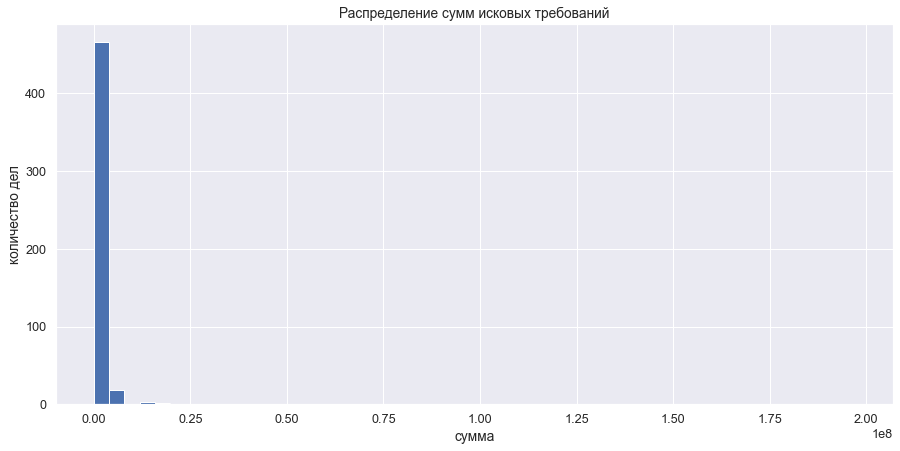

In [429]:
loaded_df_final_result['amount_claimed'].hist(bins = 50, figsize = (15,7))
plt.xlabel('сумма')
plt.ylabel('количество дел')
plt.title('Распределение сумм исковых требований')
plt.show()

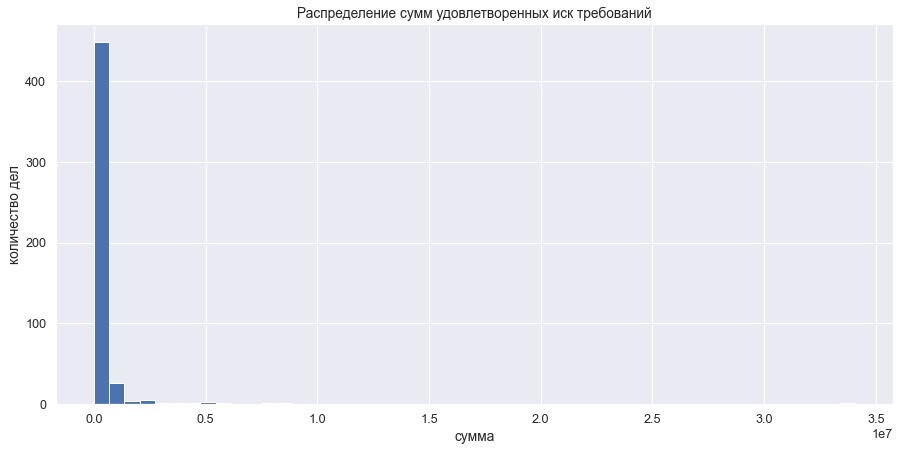

In [430]:
loaded_df_final_result['amount_satisfied'].hist(bins = 50, figsize = (15,7))
plt.xlabel('сумма')
plt.ylabel('количество дел')
plt.title('Распределение сумм удовлетворенных иск требований')
plt.show()

In [529]:
len(loaded_df_final_result.query('amount_satisfied < 500000'))

434

In [530]:
len(loaded_df_final_result.query('amount_claimed < 500000'))

362

In [531]:
df_query_satisfaction = loaded_df_final_result.query('amount_satisfied < 500000') # срез 
df_query_amount = loaded_df_final_result.query('amount_claimed < 500000')

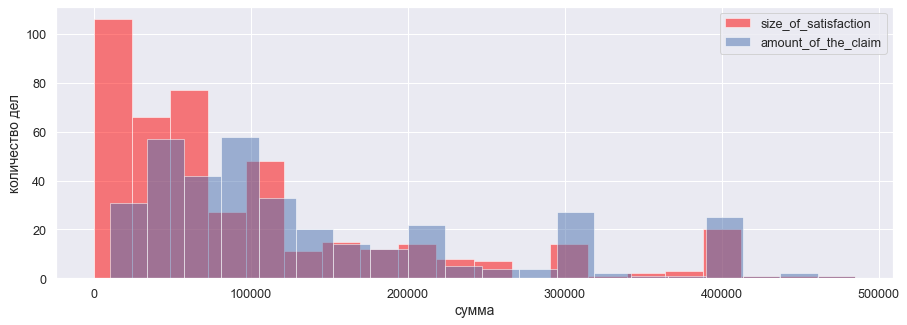

In [532]:
df_query_satisfaction['amount_satisfied'].hist(bins = 20, figsize = (15,5), alpha=0.5, color='red')
df_query_amount['amount_claimed'].hist(bins = 20, figsize = (15,5), alpha=0.5)

plt.legend(['size_of_satisfaction', 'amount_of_the_claim'])
plt.xlabel('сумма')
plt.ylabel('количество дел')
plt.show()

Срез репрезентативной части данных на гистограммах хорошо показывает:
- правостороннюю скошенность распределений;
- больше число 0 или околонулевых удовлетовренных сумм компенсаций, по крайней мере, до 100 тыс. руб.
- истцы заходя с процесс с очень вариабельными и отклоняющимися от ср. размере компенсаций в рамках релевантной суд практики

### Некоторые категориальные переменные

#### Месяц принятия решения


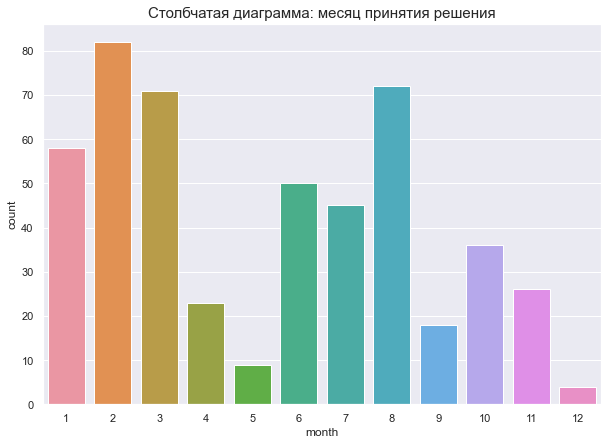

In [434]:
sns.set(rc={'figure.figsize':(10,7)})

plt.title('Столбчатая диаграмма: месяц принятия решения', fontsize=15)
sns.countplot(x='month', data=loaded_df_final_result)
plt.show()

Учитывая исследуемые периоды (01062023-31082023, 01012023-31032023, 01012024-31032024, 01092023-30112023), причина большей частотности зимних месяцев понятна, и сравнивать их с летними и осенними былоо бы некорректно. Однако отметим, что даже в этом случае август является вторым по частотности после января. При этом в выборку попали также нецелевые месяцы.

#### Распределение по годам

In [435]:
loaded_df_final_result['decision_date'].apply(lambda x: x.year).value_counts()

2023    381
2024    113
Name: decision_date, dtype: int64

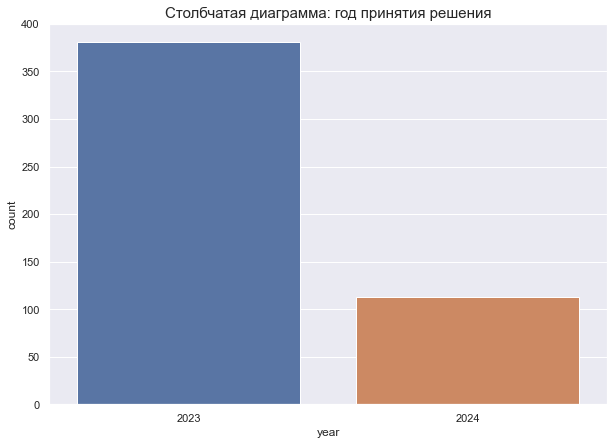

In [436]:
sns.set(rc={'figure.figsize':(10,7)})

plt.title('Столбчатая диаграмма: год принятия решения', fontsize=15)
sns.countplot(x='year', data=loaded_df_final_result)
plt.show()

**Выведем распределение медианных значений заявленных и удовлетворенных сумм по годам**

In [437]:
import warnings
warnings.filterwarnings("ignore")

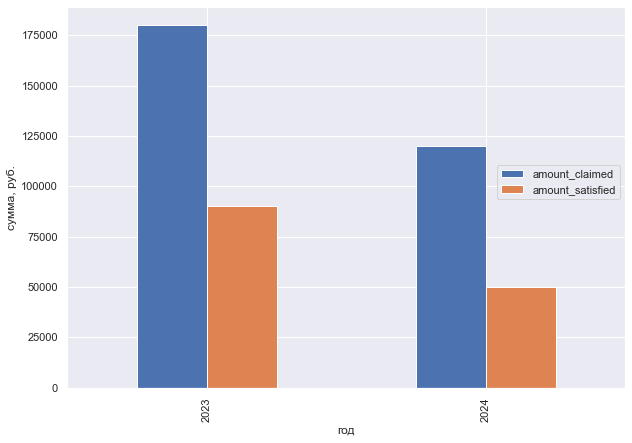

In [438]:
loaded_df_final_result.groupby('year')['amount_claimed', 'amount_satisfied'].median().plot.bar()
plt.legend(['amount_claimed', 'amount_satisfied'], bbox_to_anchor=(1, 0.6))

plt.xlabel('год')
plt.ylabel('сумма, руб.')
plt.show()

Здесь аналогично: 2024 представлен менее репрезентативно, чем 2023

#### Распределение по судам (нас интересуют АСНСО и АСГМ)

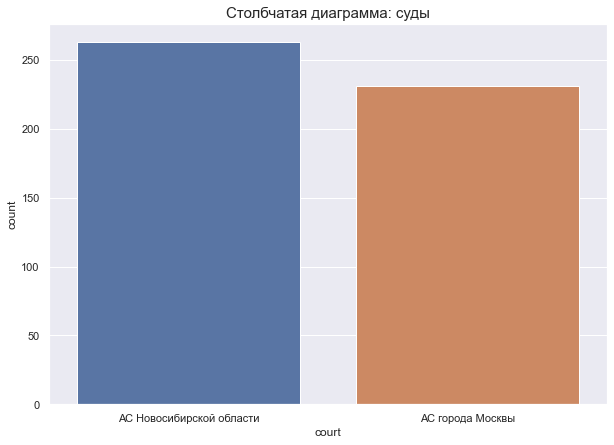

In [439]:
sns.set(rc={'figure.figsize':(10,7)})

plt.title('Столбчатая диаграмма: суды', fontsize=15)
sns.countplot(x='court', data=loaded_df_final_result)
plt.show()

**Выведем распределение медианных значений заявленных и удовлетворенных сумм по судам**

In [440]:
from itertools import cycle, islice
my_colors = list(islice(cycle(['b', 'r', 'g', 'y', 'k']), None, len(loaded_df_final_result)))

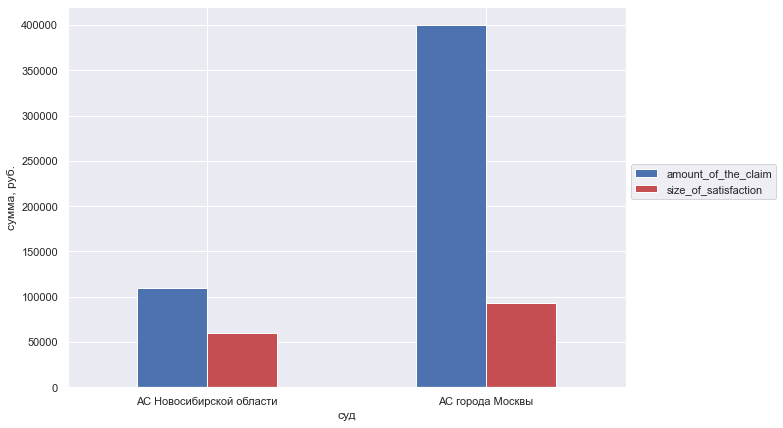

In [441]:
loaded_df_final_result.groupby('court')['amount_claimed', 'amount_satisfied'].median().plot.bar(color=my_colors)
plt.legend(['amount_of_the_claim', 'size_of_satisfaction'], bbox_to_anchor=(1, 0.6))
plt.xticks(rotation=0)
plt.xlabel('суд')
plt.ylabel('сумма, руб.')
plt.show()

**А это очень интересный график: хорошо показывает разницу между регионами )))**

#### Корреляционная матрица для количественных признаков

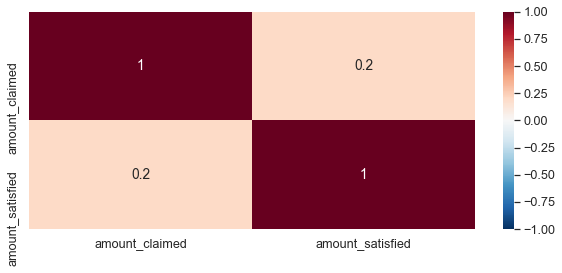

In [494]:
sns.set(font_scale=1.15)
plt.figure(figsize=(10,4))
sns.heatmap(
    loaded_df_final_result[['amount_claimed', 'amount_satisfied']].corr(),        
    cmap='RdBu_r', # задаём цветовую схему
    annot=True, # рисуем значения внутри ячеек
    vmin=-1, vmax=1); # указываем начало цветовых кодов от -1 до 1.

Корреляция 0.2 для `amount_satisfied`  и `amount_claimed`  указывает на слабую положительную линейную связь между этими двумя переменными. Слабый характер между, казалось, явно связанными переменными могут указывать на то, что:

1) большинство исков удовлетворяются частично;

2) влияние других факторов

3) наличие выбросов и сильная скошенность распределения в данных: например, очень большие заявленные суммы, которые не были удовлетворены + если большинство заявленных сумм сильно варьируются, а удовлетв-е находятся в узком диапазоне, это может снизить корреляцию.

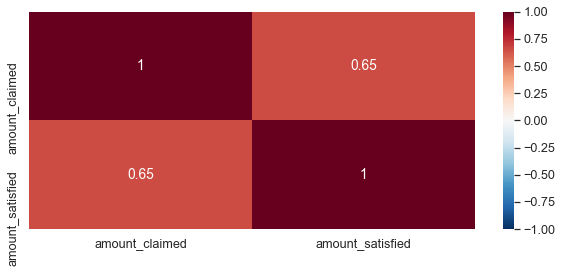

In [498]:
sns.set(font_scale=1.15)
plt.figure(figsize=(10,4))
sns.heatmap(
    loaded_df_final_result[['amount_claimed', 'amount_satisfied']].query('amount_claimed < 1000000').corr(),        
    cmap='RdBu_r', # задаём цветовую схему
    annot=True, # рисуем значения внутри ячеек
    vmin=-1, vmax=1); # указываем начало цветовых кодов от -1 до 1.

**На срезе по затребованным суммам до 1 млн руб, корр-я выросла более чем в 3 раза, что подтверждает справедливость указанных выше замечаний**

**Теперь посмотрим на диаграмму рассеяния для `size_of_satisfaction` & `amount_of_the_claim` (срез до 500 тыс.руб.)**

Text(0.5, 1.0, 'Диаграмма рассеяния — сумма иска — размер удовлетворенных требований')

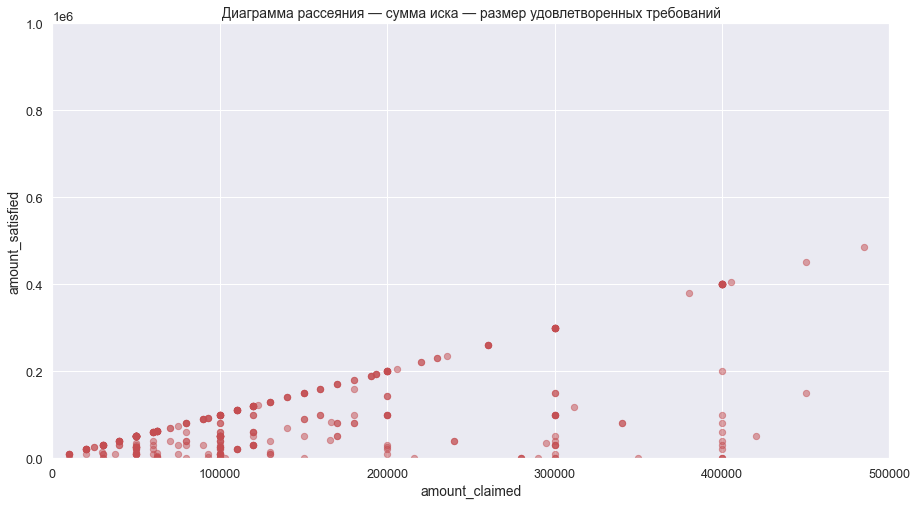

In [505]:
# check
loaded_df_final_result.query('amount_claimed < 500000').plot(kind='scatter',
        y='amount_satisfied' , x='amount_claimed', alpha=0.5, subplots=True, figsize=(15,8), c = 'r', s = 40)
plt.ylim(0, 1000000)
plt.xlim(0, 500000)
plt.title('Диаграмма рассеяния — сумма иска — размер удовлетворенных требований')

### Анализ значимости слов, содержащихся в тексте судебных решений

---

Для анализа значимости слов в текстах, извлеченных с веб-страниц, можно использовать метод TF-IDF (Term Frequency-Inverse Document Frequency). Этот метод позволяет оценить важность слова в контексте документа относительно всей коллекции документов.

In [506]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

In [508]:
def get_text_from_url(url):
    """Функция для получения текста с веб-страницы по URL."""
    driver.get(url)
    soup = BeautifulSoup(driver.page_source, 'html.parser')
    return soup.get_text(separator=' ', strip=True)

def analyze_word_significance(df):
    """
    Функция для анализа значимости слов в текстах.
    :param df: DataFrame, содержащий столбец 'link' с URL-адресами.
    :return: Series с важностью слов, отсортированная по убыванию.
    """
    # Получение текстов со всех ссылок
    texts = [get_text_from_url(url) for url in tqdm(df['link'], desc="Extracting texts")]
    
    # Загрузка стоп-слов для русского языка
    nltk.download('stopwords')
    russian_stop_words = stopwords.words('russian')
    
    # Инициализация TF-IDF Vectorizer: преобразуем тексты в числовую матрицу (770 x 1000), ограничив кол-о столбцов 
    # 1000 самыми частотными токенами
    vectorizer = TfidfVectorizer(max_features=1000, stop_words=russian_stop_words)
    
    # Применение TF-IDF к текстам
    tfidf_matrix = vectorizer.fit_transform(texts)
    
    # Преобразование результата в DataFrame
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
    
    # Агрегация значимости слов по всем документам
    word_significance = tfidf_df.sum().sort_values(ascending=False)
    
    return word_significance

In [515]:
word_significance_tfidf = analyze_word_significance(df_result)

Extracting texts: 100%|██████████████████████████████████████████████████████████████| 770/770 [19:41<00:00,  1.53s/it]
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lexme\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [512]:
def plot_word_significance(word_significance, top_n=20):
    """
    Функция для визуализации значимости слов.
    :param word_significance: Series-object с важностью слов
    :param top_n: количество самых значимых слов для отображения на графике.
    """
    # Выбор топ-N слов
    top_words = word_significance.head(top_n)
    
    # Создание графика
    plt.figure(figsize=(10, 6))
    top_words.plot(kind='bar', color='skyblue')
    plt.title(f'Top {top_n} The Most Significant Words')
    plt.xlabel('Words')
    plt.ylabel('TF-IDF Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

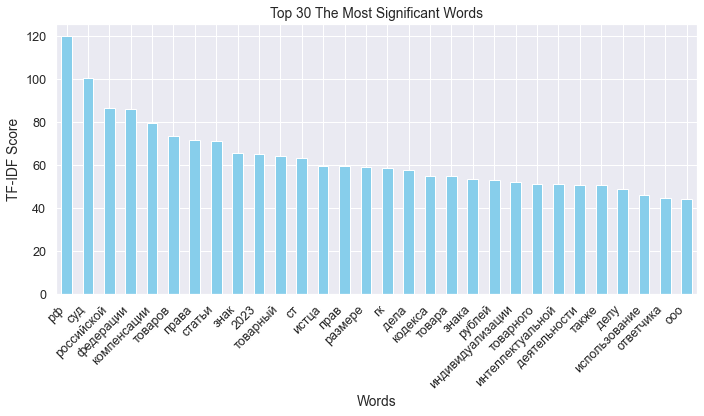

In [535]:
plot_word_significance(word_significance_tfidf, top_n=30)

**Топ 30 самых значимых слов хорошо отражают особенности юридической предметной области + подтверждает, что собранная парсером выборка является адекватной текстовому запросу пользователя.**